In [8]:
import os
import tarfile
import numpy as np
# import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import corner 
from tqdm import tqdm
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
# plt.rcParams['text.usetex'] = False
# plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'


#Another option for plotting
# pip install scienceplots
import scienceplots 
plt.style.use('science')


# #Some colors that Pablo likes:
colors = [
    "#1f77b4", # Vivid blue
    "#8f623b", # Bright orange
    "#2ca02c", # Rich green
    "#d62728", # Strong red
    "#9467bd", # Deep purple
    "#8c564b", # Brownish-pink
    "#e377c2", # Pink
    "#7f7f7f", # Medium gray
    "#bcbd22", # Lime green
    "#17becf", # Cyan
    "#2A2EAC", # Dark blue
    "#637939", # Olive green
    "#8c6d31", # Bronze
    "#843c39", # Dark red
    "#ad494a", # Reddish brown
    "#d6616b", # Soft red
    "#e7ba52", # Golden yellow
    "#7b4173", # Dark purple
    "#a55194", # Mauve
    "#ce6dbd", # Light purple
]

colors_sets = [
    "#ff7f0e",

    "#1f77b4",

    "#2ca02c",
    "#d62728",
    
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
    '#1f77b4',  # muted blue
    'r',  
] 

markers = [
    "o",  # Circle
    "^",  # Triangle up
    "s",  # Square
    "P",  # Plus (filled)
    "*",  # Star
    "X",  # X (filled)
    "D",  # Diamond
    "H",  # Hexagon
]


colors_models = colors


Selected_element=50
Selected_element_name="Sn"

color_train=colors_sets[9]
color_validation='orange'
color_test=colors_sets[3]

marker_train='s'
marker_validation='*'
marker_test='o'



size_train=30
size_validation=80
size_test=35

alpha_train=0.8
alpha_validation=0.9
alpha_test=0.4

models = [ 'ME2', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', \
        'UNEDF1']#Here I am copying all the models with Charge Raidus and Masses

models_selected = [ 'ME2', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', \
        'UNEDF1']

heterogeneous_data_type = ['BE', 'ChRad', 'CPn', 'CPp', 'PEn', 'PEp', 'QDB2n', 'QDB2p', 'QDB4n', 'QDB4p', 'MRadN', 'MRadP']
num_properties = 2

In [9]:
CR_experimental = pd.read_csv('data/charge_radii.csv') # I download the radii data separately
CR_experimental.rename(columns = {'z' : 'Z', 'n' : 'N'}, inplace = True) # Rename the column N, Z

In [10]:
# This cell helps you to extract a dictionary that contains all the nuclei with BE and radius predictions of all the models we have
models_data_sets = {}
for model in models:
    Data_Values = pd.read_hdf("./data./selected_data.h5", key = model)
    models_data_sets[model] = {"N" : Data_Values["N"], "Z" : Data_Values["Z"], "BE" : Data_Values["BE"], 'ChRad': Data_Values['ChRad']}


filtered_NZ = np.array([models_data_sets[models_selected[0]]['N'].tolist(), models_data_sets[models_selected[0]]['Z'].tolist() ]).T


## Necessary Function

In [4]:
def separate_points_random(list1,random_chance):
    """
    Separates points in list1 into two groups randomly

    """
    train = []
    test = []

    train_list_coordinates=[]
    test_list_coordinates=[]


    for i in range(len(list1)):
        point1=list1[i]
        val=np.random.rand()
        if val<=random_chance:
            train.append(point1)
            train_list_coordinates.append(i)
        else:
            test.append(point1)
            test_list_coordinates.append(i)

    return np.array(train), np.array(test), np.array(train_list_coordinates), np.array(test_list_coordinates)

def separate_points_distance(list1, list2, distance):
    """
    Separates points in list1 into two groups based on their proximity to any point in list2.

    :param list1: List of (x, y) tuples.
    :param list2: List of (x, y) tuples.
    :param distance: The threshold distance to determine proximity.
    :return: Two lists - close_points and distant_points.
    """
    train = []
    test = []

    train_list_coordinates=[]
    test_list_coordinates=[]

    for i in range(len(list1)):
        point1=list1[i]
        close = False
        for point2 in list2:
            if np.linalg.norm(np.array(point1) - np.array(point2)) <= distance:
                close = True
                break
        if close:
            train.append(point1)
            train_list_coordinates.append(i)
        else:
            test.append(point1)
            test_list_coordinates.append(i)

    return np.array(train), np.array(test), np.array(train_list_coordinates), np.array(test_list_coordinates)

def separate_points_distance_allSets(list1, list2, distance1, distance2):
    """
    Separates points in list1 into three groups based on their proximity to any point in list2.

    :param list1: List of (x, y) tuples.
    :param list2: List of (x, y) tuples.
    :param distance: The threshold distance to determine proximity.
    :return: Two lists - close_points and distant_points.
    """
    train = []
    validation=[]
    test = []

    train_list_coordinates=[]
    validation_list_coordinates=[]
    test_list_coordinates=[]

    for i in range(len(list1)):
        point1=list1[i]
        close = False
        for point2 in list2:
            if np.linalg.norm(np.array(point1) - np.array(point2)) <= distance1:
                close = True
                break
        if close:
            train.append(point1)
            train_list_coordinates.append(i)
        else:
            close2=False
            for point2 in list2:
                if np.linalg.norm(np.array(point1) - np.array(point2)) <= distance2:
                    close2 = True
                    break
            if close2==True:
                validation.append(point1)
                validation_list_coordinates.append(i)
            else:
                test.append(point1)
                test_list_coordinates.append(i)                

    return np.array(train_list_coordinates),  np.array(validation_list_coordinates), np.array(test_list_coordinates)

In [5]:
def LDM_extended(params, x): 
    #x = (n,z)
    #params= parameters (volume, surface, curv, sym, ssym, sym_2, Coulomb)
    
    n=x[0]
    z=x[1]
    A = n + z
    I = (n-z)/(n+z)


    return A*params[0] + params[1] * A ** (2/3) + params[2] * A ** (1/3)  +  params[3] * I ** 2*A + \
                + params[4] * (I ** 2) * A ** (2/3) + params[5] * (I ** 4)*A + params[6]*((z**2)/((A)**(1/3))) 

def isospin_radii_model(A, N, Z, r_a, b ,c):
    return r_a * A** (1/3) * (1 - b * (N - Z)/A + c/A)

def filtered_NZ_extraction(filtered_NZ):
    #We want to create a function that takes only even-even nuclei with N,Z >= 8
    filtered_NZ_new = []
    for isotope in filtered_NZ:
        if ((isotope[0] >= 8) & (isotope[1] >=8)) & ((isotope[0]%2 == 0) & (isotope[1]%2 == 0)): # Sort the even-even isotope with proton and neutron number 8 or above
            filtered_NZ_new.append(isotope)
    filtered_NZ_new  = np.array(filtered_NZ_new)
    return filtered_NZ_new

def unified_NZ_extraction(models_data_sets, models_selected, filtered_NZ):
    #We want to create a function that extracts nuclei that exist in every models
    for model in models_selected:
        filtered_NZ_new = []
        for isotope in filtered_NZ:
            if ( (isotope[0] == models_data_sets[model]['N']) & (isotope[1] == models_data_sets[model]['Z']) ).any(): # Choose nuclei that are contained in each model
                filtered_NZ_new.append(isotope)
        filtered_NZ = np.array(filtered_NZ_new) #update our new list of isotope and repeat this for every model
    filtered_NZ_df = pd.DataFrame({'N' : filtered_NZ.T[0], 'Z' : filtered_NZ.T[1]})
    return filtered_NZ_new, filtered_NZ_df

def selected_models_data_sets_extraction(models_data_sets, models_selected, filtered_NZ_df, property):
    #We want to create dataframe that contains all the model predictions of a property of interest
    selected_models_data_sets = pd.DataFrame(filtered_NZ_df.copy()) #Initiate the dataframe by the proton and neutron number
    for model in models_selected:
        # Convert the model's dataset to a dataframe (if not already)
        model_df = pd.DataFrame(models_data_sets[model])

        # Merge with selected_models_data_sets to keep only matching isotopes
        merged_df = pd.merge(selected_models_data_sets, model_df, on=['N', 'Z'], how='inner')

        # Update selected_models_data_sets to include only the common isotopes
        selected_models_data_sets = merged_df[['N', 'Z'] + [col for col in selected_models_data_sets.columns if col not in ['N', 'Z']]]

        # Add the model's predictions for the property
        selected_models_data_sets[model] = merged_df[property]

    return selected_models_data_sets

def models_output_extraction(selected_models_data_sets, train_coordinates, validation_coordinates, test_coordinates):
    #Technically rearrange the columns of the selected_models_data_sets and separate into intrapolation and extrapolation part
    models_output = selected_models_data_sets.copy()
    models_output['A'] = models_output['N'] + models_output['Z'] # Put the mass number in our dataframe
    cols = list(models_output.columns)
    cols[2], cols[-1] = cols[-1], cols[2] # Rearranging columns 
    models_output = models_output[cols]

    models_output_train = models_output.iloc[train_coordinates] # Training regions
    models_output_validation = models_output.iloc[validation_coordinates] # Validation regions
    models_output_test = models_output.iloc[test_coordinates] # Test regions
    return [models_output, models_output_train, models_output_validation, models_output_test]


def clip_sort(df, N_min, N_max, Z_min, Z_max):
        mask_N = df['N'].between(N_min, N_max)
        out_N = df.loc[mask_N].copy()
        
        mask_Z = out_N['Z'].between(Z_min, Z_max)
        out_Z = out_N.loc[mask_Z].copy()

        return out_Z

def filtered_models_output_extraction(models_output, train_idx, val_idx, test_idx, \
                                      stable_coordinates_df, Z_range, N_range = None):
    """
    Extract [all, train, val, test] slices filtered by Z and N ranges, then sorted.

    Parameters
    ----------
    models_output : pd.DataFrame
        Must contain columns 'Z', 'N', each model column, and 'truth'.
    train_coordinates / validation_coordinates / test_coordinates : sequence[int]
        Positional indices for .iloc to define splits.
    Z_range : (int, int) or None
        Inclusive range of proton numbers to keep. None => no Z filter.
        Use (Z, Z) to get a single element.
    N_range : (int, int)
        Inclusive neutron-number range to keep.

    Returns
    -------
    list[pd.DataFrame] : [all_df, train_df, val_df, test_df]
    """

    if Z_range == None:
        raise ValueError('Must specify the range of Z')
    
    if N_range is None:
        N_range = (0, 300)

    Z_min, Z_max = Z_range[0], Z_range[1]
    N_min, N_max = N_range[0], N_range[1]

    models_output_stable = pd.merge(models_output, stable_coordinates_df, on = ['N', 'Z'], how = 'inner')


    all_df  = clip_sort(models_output, N_min, N_max, Z_min, Z_max)
    train_df = clip_sort(models_output.iloc[train_idx], N_min, N_max, Z_min, Z_max)
    val_df   = clip_sort(models_output.iloc[val_idx], N_min, N_max, Z_min, Z_max)
    test_df  = clip_sort(models_output.iloc[test_idx], N_min, N_max, Z_min, Z_max)
    stable_df = clip_sort(models_output_stable, N_min, N_max, Z_min, Z_max)

    return [all_df, train_df, val_df, test_df, stable_df]


def filtered_predictions_all_elements(models_output, train_idx, val_idx, test_idx, \
                                            stable_coordinates_df, Zs=None):
    """
    Lightweight orchestrator:
    - Picks the Zs to process (defaults to all in models_output).
    - For each Z, calls your two extractors (which already handle N-range & sorting).
    - Returns a dict: Z -> {'all','train','val','test','stable'} DataFrames.
    """
    if Zs is None:
        Zs = sorted(models_output['Z'].unique())

    predictions_dict = {}

    for Z in Zs:
        [all_df, train_df, val_df, test_df, stable_df]= filtered_models_output_extraction(
            models_output,
            train_idx,
            val_idx,
            test_idx,
            stable_coordinates_df,
            Z_range = (Z,Z),
            N_range = None
        )

        predictions_dict[Z] = {
            'all': all_df,
            'train': train_df,
            'val': val_df,
            'test': test_df,
            'stable': stable_df
        }
    return predictions_dict



def filtered_models_output_stable_extraction(Selected_element, models_output, stable_coordinates):
    # Extract models output dataframe for stable isotope for a specific element
    Z_range = (Selected_element, Selected_element) # Choose element we want to analyze
    N_range = (0,300)
    stable_isotopes = []
    for isotope in stable_coordinates:
        if isotope[1] == Selected_element: #Choose isotope that has the same proton number
            stable_isotopes.append(isotope)
    stable_isotopes = np.array(stable_isotopes)
    
    filtered_models_output_stable = models_output[(models_output['Z'] >= Z_range[0]) & (models_output['Z'] <= Z_range[1])\
                                                 & (models_output['N'] >= N_range[0]) & (models_output['N'] <= N_range[1]) & models_output['N'].isin(stable_isotopes.T[0])]
    return filtered_models_output_stable

def filtered_models_output_dict_extraction(Selected_elements, key_name, models_output, train_coordinates, validation_coordinates, test_coordinates, stable_coordinates):
    # This functions helps me to create the filtered models output for different isotopes at the same time and store them in a dictionary
    filtered_models_output_dict = {} # Initiate dictionary
    for j in Selected_elements:
        key = f"{key_name}" + f"{int(j)}" # name is the key-value pair in the dictionary
        # The line below store the list of filtered models output for a specific element in the dictionary
        filtered_models_output_dict[key] = filtered_models_output_extraction(int(j), models_output, train_coordinates, validation_coordinates, test_coordinates)
        # The line below add to the list we have above the stable isotopes into our list
        filtered_models_output_dict[key].append(filtered_models_output_stable_extraction(int(j), models_output, stable_coordinates))
    filtered_models_output_dict.keys() # This is just to check if I had the right name for the list
    return filtered_models_output_dict

def models_PC_output(Vt_hat, model_predictions, predictions_mean, models_output):
    # This fucntions returns the dataframe of 
    models_PC = {}
    models_PC['N'] = models_output['N']
    models_PC['Z'] = models_output['Z']
    models_PC['A'] = models_output['N'] + models_output['Z']
    models_PC['PC_0'] = predictions_mean

    for i in range(len(Vt_hat)):
        models_PC['PC_' + str(i+1)] = Vt_hat[i].dot(model_predictions.T)
    model_PC = pd.DataFrame(models_PC)
    return model_PC

# Right now there are some more functions that we need for the statistical interference but we did not write it here yet
def USVt_hat_extraction(U,S,Vt, components_kept):
    U_hat = np.array([U.T[i] for i in range(components_kept)]).T
    S_hat = S[:components_kept]
    Vt_hat = np.array([Vt[i]/S[i] for i in range(components_kept)])
    return U_hat, S_hat, Vt_hat

def super_params(X,y):
    X_T_X = X.T.dot(X)
    X_T_X_inv = np.linalg.inv(X_T_X)
    super_param = X_T_X_inv.dot(X.T).dot(y) 
    return super_param

def weights_params_translation(super_params, Vt_hat):
    model_weights = np.dot(super_params, Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0]))
    model_weights = np.array(model_weights)
    return model_weights

def residuals_calculator(model_weights, model_predictions_list, models_output_list):
    #Note that we for every models output list we put all nuclei first, and then train, validation, test region
    supermodel_full = model_weights.dot(model_predictions_list[0].T)
    supermodel_train = model_weights.dot(model_predictions_list[1].T)
    supermodel_validation = model_weights.dot(model_predictions_list[2].T)
    supermodel_test = model_weights.dot(model_predictions_list[3].T)

    supermodel_residuals_full = supermodel_full-models_output_list[0]['truth'].tolist()
    supermodel_residuals_train=supermodel_train-models_output_list[1]['truth'].tolist()
    supermodel_residuals_validation= supermodel_validation-models_output_list[2]['truth'].tolist()
    supermodel_residuals_test = supermodel_test-models_output_list[3]['truth'].tolist()

    return supermodel_residuals_full, supermodel_residuals_train, supermodel_residuals_validation, supermodel_residuals_test

def supermodel_residuals_calculator(components_kept, model_predictions, predictions_mean, models_output, models_output_list, model_predictions_list, U, S, Vt):
    U_hat, S_hat, Vt_hat = USVt_hat_extraction(U,S,Vt, components_kept) # This gives you the approximation matrix
    # Note that we for any list that we create, we will put full dataset first, and then train, validation, test respectively
    # models_PC_train = models_PC_output(Vt_hat, model_predictions_list[1], predictions_mean) # This gives you the matrix of the PCs
    
    # key_list_PCs=list(models_PC_train.keys()) # columns' names of the PCs matrix

    models_PC_train = models_PC_output(Vt_hat, model_predictions, predictions_mean, models_output)
    X = models_PC_train.values[:,4:]# This is the matrix of the PCs
    # print(X.shape)
    y = models_output['truth'] - predictions_mean
    beta = super_params(X,y) #Calculate the best OLS beta
    model_weights = weights_params_translation(beta, Vt_hat) #Translate from the PCs' params to models' weights
    print(model_weights)

    supermodel_residuals_full, supermodel_residuals_train, supermodel_residuals_validation, supermodel_residuals_test = residuals_calculator(model_weights,\
                                                                                                            model_predictions_list, models_output_list)

    return [supermodel_residuals_full, supermodel_residuals_train, supermodel_residuals_validation, supermodel_residuals_test]

def PC_RMSE_calculator(components_kept, model_predictions, predictions_mean, models_output, models_output_list, model_predictions_list, U, S, Vt):
    # model_predictions and predictions_mean are variables that related to PCA decomposition, and models_output part are related to
    # the part where we want to calculate RMSE
    supermodel_residuals_full, supermodel_residuals_train, supermodel_residuals_validation, supermodel_residuals_test = supermodel_residuals_calculator(\
                                                            components_kept, model_predictions, predictions_mean, models_output, models_output_list, model_predictions_list, U, S, Vt)
    sigma_train=np.sqrt(np.sum(supermodel_residuals_train**2) / len(supermodel_residuals_train) )
    sigma_validation=np.sqrt(np.sum(supermodel_residuals_validation**2) / len(supermodel_residuals_validation) )
    sigma_test=np.sqrt(np.sum(supermodel_residuals_test**2) / len(supermodel_residuals_test) )
    sigma_full=np.sqrt(np.sum(supermodel_residuals_full**2) / len(supermodel_residuals_full) )
    print(sigma_train)

    return [sigma_full,sigma_train,sigma_validation,sigma_test]

def rndm_m_radius_calculator(model_weights, filtered_model_predictions, samples):
    rndm_m_radius = []
    for i in range(len(model_weights)):

        yvals_rand_radius= filtered_model_predictions.dot(model_weights[i].T)
        # else:
        #     yvals_rand= X_full_filtered.T.dot(theta_rand[i][0:-1])
    
        rndm_m_radius.append(yvals_rand_radius +
                       np.random.multivariate_normal(np.full(
                           len(yvals_rand_radius)
                           ,0), np.diag(1.0 * np.full(len(yvals_rand_radius),1.0 * samples[i][-1]**2 ) )))  
        
    lower_radius = np.percentile(rndm_m_radius, 2.5, axis = 0)
    median_radius = np.percentile(rndm_m_radius, 50, axis = 0)
    upper_radius = np.percentile(rndm_m_radius, 97.5, axis = 0)

    return [lower_radius, median_radius, upper_radius]


def rndm_m_random_calculator(filtered_model_predictions, samples, Vt_hat):
    """
    Generates posterior predictive samples and credible intervals.

    Args:
        filtered_model_predictions (numpy.ndarray): Model predictions.
        samples (numpy.ndarray): Gibbs samples `[beta, sigma]`.
        Vt_hat (numpy.ndarray): Normalized right singular vectors.

    Returns:
        tuple[numpy.ndarray, list[numpy.ndarray]]:
            - `rndm_m` (numpy.ndarray): Posterior predictive samples.
            - `[lower, median, upper]` (list[numpy.ndarray]): Credible interval arrays.
    """
    np.random.seed(142858)
    rng = np.random.default_rng()

    theta_rand_selected = rng.choice(samples, 50000, replace=False)

    # Extract betas and noise std deviations
    betas = theta_rand_selected[:, :-1]  # shape: (10000, num_models - 1)
    noise_stds = theta_rand_selected[:, -1]  # shape: (10000,)

    # Compute model weights: shape (10000, num_models)
    default_weights = np.full(Vt_hat.shape[1], 1 / Vt_hat.shape[1])
    model_weights_random = (
        betas @ Vt_hat + default_weights
    )  # broadcasting default_weights

    # Generate noiseless predictions: shape (10000, num_data_points)
    yvals_rand_radius = (
        model_weights_random @ filtered_model_predictions.T
    )  # dot product

    # Add Gaussian noise with std = noise_stds (assume diagonal covariance)
    # We'll use broadcasting: noise_stds[:, None] * standard normal noise
    noise = rng.standard_normal(yvals_rand_radius.shape) * noise_stds[:, None]
    rndm = yvals_rand_radius + noise

    # Compute credible intervals
    lower_radius = np.percentile(rndm, 2.5, axis=0)
    median_radius = np.percentile(rndm, 50, axis=0)
    upper_radius = np.percentile(rndm, 97.5, axis=0)

    return rndm, [lower_radius, median_radius, upper_radius]

def rndm_m_random_calculator_student_t(filtered_model_predictions, samples, Vt_hat, nu):
    """
    Generates posterior predictive samples and credible intervals with Student-t noise.

    Args:
        filtered_model_predictions (numpy.ndarray): Model predictions (num_points x num_models).
        samples (numpy.ndarray): Gibbs/MH samples with columns [betas..., sigma].
        Vt_hat (numpy.ndarray): Normalized right singular vectors (num_betas x num_models).
        nu (float): Degrees of freedom for the Student-t noise.

    Returns:
        tuple[numpy.ndarray, list[numpy.ndarray]]:
            - rndm_m (numpy.ndarray): Posterior predictive samples.
            - [lower, median, upper] (list[numpy.ndarray]): 95% credible intervals per point.
    """
    np.random.seed(142858)
    rng = np.random.default_rng()

    # Safety: don't sample more rows than available
    n_draws = min(50_000, len(samples))
    theta_rand_selected = rng.choice(samples, n_draws, replace=False)

    # Extract betas and noise std deviations
    betas = theta_rand_selected[:, :-1]   # shape: (n_draws, num_betas)
    noise_stds = theta_rand_selected[:, -1]  # shape: (n_draws,)

    # Compute model weights: shape (n_draws, num_models)
    default_weights = np.full(Vt_hat.shape[1], 1.0 / Vt_hat.shape[1])
    model_weights_random = betas @ Vt_hat + default_weights  # broadcast default_weights

    # Noiseless predictions: shape (n_draws, num_points)
    yvals_rand_radius = model_weights_random @ filtered_model_predictions.T

    # --- Student-t noise instead of Gaussian ---
    # Draw standard t_ν noise and scale by per-draw sigma
    t_noise = rng.standard_t(df=nu, size=yvals_rand_radius.shape)           # ~ t_ν(0, 1)
    noise   = t_noise * noise_stds[:, None]                                  # scale by σ

    rndm = yvals_rand_radius + noise

    # Credible intervals
    lower_radius  = np.percentile(rndm, 2.5, axis=0)
    median_radius = np.percentile(rndm, 50,  axis=0)
    upper_radius  = np.percentile(rndm, 97.5, axis=0)

    return rndm, [lower_radius, median_radius, upper_radius]


def coverage(percentiles, rndm_m, models_output, truth_column):
    """
    Calculates coverage percentages for credible intervals.

    Args:
        percentiles (list[int]): Percentiles to evaluate (e.g., `[5, 10, ..., 95]`).
        rndm_m (numpy.ndarray): Posterior samples of predictions.
        models_output (pandas.DataFrame): DataFrame containing true values.
        truth_column (str): Name of column with true values.

    Returns:
        list[float]: Coverage percentages for each percentile.
    """
    #  How often the model’s credible intervals actually contain the true value
    data_total = len(rndm_m.T)  # Number of data points
    M_evals = len(rndm_m)  # Number of samples
    data_true = models_output[truth_column].tolist()

    coverage_results = []

    for p in percentiles:
        count_covered = 0
        for i in range(data_total):
            # Sort model evaluations for the i-th data point
            sorted_evals = np.sort(rndm_m.T[i])
            # Find indices for lower and upper bounds of the credible interval
            lower_idx = int((0.5 - p / 200) * M_evals)
            upper_idx = int((0.5 + p / 200) * M_evals) - 1
            # Check if the true value y[i] is within this interval
            if sorted_evals[lower_idx] <= data_true[i] <= sorted_evals[upper_idx]:
                count_covered += 1
        coverage_results.append(count_covered / data_total * 100)

    return coverage_results

In [99]:
def plot_model_predictions(filtered_models_output_list, models_selected, Selected_element_name):
    plt.rc("xtick", labelsize=30)
    plt.rc("ytick", labelsize=30)

    plt.rcParams['text.usetex'] = True
    # plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

    filtered_models_output= filtered_models_output_list[0]
    filtered_models_output_train= filtered_models_output_list[1]
    filtered_models_output_validation= filtered_models_output_list[2]
    filtered_models_output_test = filtered_models_output_list[3]
    filtered_models_output_stable = filtered_models_output_list[4]
    
    fig, ax = plt.subplots(figsize=(10,8), dpi=150)
    i = 0
    for model in models_selected:
        plt.plot(filtered_models_output['N'], filtered_models_output[model],label = model, color=colors[i], alpha = 0.9,linewidth=5, zorder = 1)
        i+=1
    ax.scatter(x = filtered_models_output_train["N"], y = filtered_models_output_train['truth'], label = "Truth-Train",  alpha = 1,color=color_train,s=200,marker=marker_train,zorder=2)

    ax.scatter(x = filtered_models_output_validation["N"], y = filtered_models_output_validation['truth'], label = "Truth-Validation", alpha = 1,color=color_validation,s=350,marker=marker_validation,zorder=2)
    
    ax.scatter(x = filtered_models_output_test["N"], y = filtered_models_output_test['truth'], label = "Truth-Test", alpha = 1,color=color_test,s=350,marker=marker_test,zorder=2)
    
    ax.scatter(x = filtered_models_output_stable["N"], y = filtered_models_output_stable['truth'], label = "Truth-Stable", alpha = 1,color='k',s=80,marker="s",zorder=2)
    
    
    
    plt.xlabel("N",fontsize=35)
    plt.ylabel(Selected_element_name+" R(fm)",fontsize=35)
    # plt.legend(fontsize=18,markerscale=1 )
    # plt.legend(fontsize=15,markerscale=1,ncol=4  )
    # plt.savefig(f'{savefig}')
    # plt.show()

def plot_filtered_naive_supermodel(filtered_naive_supermodel_list, filtered_models_output_list, filtered_models_output_stable, Z, unit, property, Constraint, title):
    plt.rc("xtick", labelsize=30)
    plt.rc("ytick", labelsize=30)

    plt.rcParams['text.usetex'] = False
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

    filtered_models_output= filtered_models_output_list[0]
    filtered_models_output_train= filtered_models_output_list[1]
    filtered_models_output_validation= filtered_models_output_list[2]
    filtered_models_output_test = filtered_models_output_list[3]
    # filtered_models_output_stable = filtered_models_output_list[4]
    
    fig, ax = plt.subplots(figsize=(10,8), dpi=150)
    
    plt.plot(filtered_naive_supermodel_list[0]["N"], filtered_naive_supermodel_list[0]['naive supermodel'], color="darkkhaki", label=f'$f^\dagger$({Constraint})',linewidth=3)
    
    color_local= "khaki"
    
    
    # plt.plot(filtered_models_output["N"], -median_simplex_local/filtered_models_output['A'], color='purple', label='$f^\dagger$(Simplex Local)',linewidth=3)
    
    # # plt.plot(filtered_models_output["N"], lower, color=color_simplex,linestyle="dashed",linewidth=3,alpha=0.8)
    # # plt.plot(filtered_models_output["N"], upper, color=color_simplex,linestyle="dashed",linewidth=3,alpha=0.8)
    
    
    # plt.plot(filtered_models_output["N"], -lower_simplex_local/filtered_models_output['A'], color="purple",linestyle="dashed",linewidth=2,alpha=0.8)
    # plt.plot(filtered_models_output["N"], -upper_simplex_local/filtered_models_output['A'], color="purple",linestyle="dashed",linewidth=2,alpha=0.8)
    
    # plt.fill_between(filtered_models_output["N"], -lower_simplex_local/filtered_models_output['A'], -upper_simplex_local/filtered_models_output['A'], color='purple',alpha=0.3)
    
    ax.scatter(x = filtered_models_output_train["N"], y = filtered_models_output_train['truth'], label = "$\mathcal{X}_0^{tr}$",  alpha = alpha_train,color=color_train,s=100,marker=marker_train,zorder=2)
    
    ax.scatter(x = filtered_models_output_validation["N"], y = filtered_models_output_validation['truth'], label = "$\mathcal{X}_0^{va}$", alpha=alpha_validation ,color=color_validation,s=100,marker=marker_validation,zorder=2)

    ax.scatter(x = filtered_models_output_test["N"], y = filtered_models_output_test['truth'], label = "$\mathcal{X}_0^{te}$", alpha = alpha_test,color=color_test,s=100,marker=marker_test,zorder=2)
    
    ax.scatter(x = filtered_models_output_stable["N"], y = filtered_models_output_stable['truth'], label = "Stable", alpha = 0.9,color='k',s=80,marker="s",zorder=2)
    
    
    
    
    
    plt.xlabel("Neutrons",fontsize=35)
    plt.ylabel(f"(Z= {Z}) $ {{\\cal {property}}}$ [{unit}]", fontsize=33)
    # plt.ylabel(Selected_element_name+ " BE/A MeV",fontsize=25)
     
    plt.legend(fontsize=20,markerscale=1,ncol=2,columnspacing=0.5)

    plt.title(f'Naive Radius Calibration with {title} component(s)', fontsize = 25)
    # plt.savefig(f'{save_fig}')
    # plt.show()

def plot_filtered_real_data_dict(Selected_elements_list, element_name, filtered_models_output_dict):
    # Selected_element_list are the name of the elements, Selected_element is the number of proton that element has.
    i = Selected_elements_list.index(element_name)# This gives you the index of the element you want to graph
    dict_keys = list(filtered_models_output_dict.keys()) # This gives you all the keys in the dictionary that we input

    plt.rc("xtick", labelsize=30)
    plt.rc("ytick", labelsize=30)
    
    plt.rcParams['text.usetex'] = False
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
    
    fig, ax = plt.subplots(figsize=(10,8), dpi=150)
    # This gives you the mean predictions of the isotope that we choose

    # color_local= "khaki"

    # This gives you training experimental data for these isotope
    ax.scatter(x = filtered_models_output_dict[dict_keys[i]][1]["N"], y = filtered_models_output_dict[dict_keys[i]][1]['truth'], label = "$\mathcal{X}_0^{tr}$",  alpha = alpha_train,color=color_train,s=100,marker=marker_train,zorder=2)
    # This gives you validation experimental data for these isotope
    ax.scatter(x = filtered_models_output_dict[dict_keys[i]][2]["N"], y = filtered_models_output_dict[dict_keys[i]][2]['truth'], label = "$\mathcal{X}_0^{va}$", alpha=alpha_validation ,color=color_validation,s=100,marker=marker_validation,zorder=2)
    # This gives you testing experimental data for these isotope
    ax.scatter(x = filtered_models_output_dict[dict_keys[i]][3]["N"], y = filtered_models_output_dict[dict_keys[i]][3]['truth'], label = "$\mathcal{X}_0^{te}$", alpha = alpha_test,color=color_test,s=100,marker=marker_test,zorder=2)
    # This gives you stable experimental data for these isotope
    ax.scatter(x = filtered_models_output_dict[dict_keys[i]][4]["N"], y = filtered_models_output_dict[dict_keys[i]][4]['truth'], label = "Stable", alpha = 0.9,color='k',s=80,marker="s",zorder=2)

def plot_filtered_something_else_dict(Selected_elements_list, element_name, Selected_element, filtered_models_output_dict, filtered_models_something_else_dict, what_you_want_to_graph):
    # plot_filtered_real_data_dict(Selected_elements_list, element_name, filtered_models_output_dict) # This plots all the experimental data
    fig, ax = plt.subplots(figsize=(10,8), dpi=150)
    index = Selected_elements_list.index(element_name) #Again, this gives you the index of the element you are trying to graph
    dict_keys = list(filtered_models_something_else_dict.keys()) # This gives you all the key of the dictionary that we want to create
    filtered_models_something_else = filtered_models_something_else_dict[dict_keys[index]][0][what_you_want_to_graph] #This is the dataframe that we want to graph from
    for i in range(len(filtered_models_something_else.columns)):
        column = list(filtered_models_something_else.columns)[i]
        plt.plot(filtered_models_something_else_dict[dict_keys[index]][0]['N'], filtered_models_something_else[column], color= colors[i], label= column,linewidth=5)

    plt.xlabel("Neutrons",fontsize=35)
    plt.ylabel(f"(Z= {Selected_element}) $ {{\\cal R}}$ [fm]", fontsize=33)
    # plt.ylabel(Selected_element_name+ " BE/A MeV",fontsize=25)
         
    plt.legend(fontsize=20,markerscale=1,ncol=2,columnspacing=0.5)
    
    # plt.title(f'{title}', fontsize = 25)
    # plt.savefig(f'{save_fig}')
    # plt.show()
# Let'steal this from Pablo like we always do

def plot_heatmap(xvals, yvals, zvals, quantity_of_interest, model):
    # Create scatter plot
    plt.rc("xtick", labelsize=10)
    plt.rc("ytick", labelsize=10)
    fig, ax = plt.subplots(figsize = (4,3), dpi = 200)
    
    sc = ax.scatter(xvals, yvals, c=zvals, s=0.5, cmap='plasma', marker = 's')
    # plt.colorbar(sc, label='Z-Value')
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(f'{quantity_of_interest}', fontsize=10) 
    cbar.ax.tick_params(labelsize=10) 
    
    plt.xlabel('Neutrons',fontsize=10)
    plt.ylabel('Protons',fontsize=10)

    ax.grid(True)
    ax.axis('equal')
    plt.title(f'{model}')
    plt.tight_layout()
    # plt.savefig(f'{savefig}')
    plt.show()

def plot_heatmap_3D(xvals, yvals, zvals, title, elev=30, azim=-60):
    # Create figure and 3D axes
    fig, ax_3d = plt.subplots(figsize=(4, 3), dpi=200, subplot_kw={'projection': '3d'})
    
    # Normalize z values
    # z_normalized = (zvals - zvals.min()) / (zvals.max() - zvals.min())
    z_normalized = zvals # This is when we want to see the actual components of the PCs
    # Define the size of the bars
    dx = dy = 1.5  # Width of the bars in the x and y directions
    dz = z_normalized  # Height of the bars (z values)

    # Create 3D bar plot
    ax_3d.bar3d(xvals, yvals, np.zeros_like(z_normalized), dx, dy, dz, color=plt.cm.plasma((zvals - zvals.min()) / (zvals.max() - zvals.min())))
    ax_3d.set_zlim(np.minimum(0, zvals.min()), zvals.max())
    # Set view angle
    ax_3d.view_init(elev=elev, azim=azim) 
    
    ax_3d.tick_params(axis='both', labelsize=8)  # Smaller font size for major ticks
    ax_3d.tick_params(axis='z', labelsize=8)
    
    # Set labels and title
    ax_3d.set_xlabel('Neutrons', fontsize = 5)
    ax_3d.set_ylabel('Protons', fontsize = 5)
    ax_3d.set_zlabel('Scaled Z', fontsize = 5)
    ax_3d.set_title(title)

    # Create a colorbar based on the plasma colormap and the normalization
    mappable = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=zvals.min(), vmax=zvals.max()))
    mappable.set_array(zvals)
    
    # Add the colorbar to the plot
    cbar = plt.colorbar(mappable, ax=ax_3d, shrink=0.5, aspect=10, location='right', pad=0.2)
    cbar.set_label(title, fontsize=5)
    cbar.ax.tick_params(labelsize=5)

    # Show plot
    # plt.show()

def plot_filtered_supermodel(supermodel_predictions_range, filtered_models_output_list, color, Z, unit, property, Constraint, title):
    plt.rc("xtick", labelsize=30)
    plt.rc("ytick", labelsize=30)

    plt.rcParams['text.usetex'] = True
    # plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
    
    lower, median, upper = supermodel_predictions_range

    filtered_models_output= filtered_models_output_list[0]
    filtered_models_output_train= filtered_models_output_list[1]
    filtered_models_output_validation= filtered_models_output_list[2]
    filtered_models_output_test = filtered_models_output_list[3]
    filtered_models_output_stable = filtered_models_output_list[4]
    
    fig, ax = plt.subplots(figsize=(10,8), dpi=150)
    
    plt.plot(filtered_models_output["N"], median, color=f'{color}', label = r'$f^\dagger(\mathbf{x}, \mathbf{b})$',linewidth=3, alpha= 0.8)
    
    plt.plot(filtered_models_output["N"], lower, color=f'{color}',linestyle="dashed",linewidth=2,alpha=0.6)
    plt.plot(filtered_models_output["N"], upper, color=f'{color}',linestyle="dashed",linewidth=2,alpha=0.6)
    
    plt.fill_between(filtered_models_output["N"], lower, upper, color= f'{color}',alpha=0.4)
    
    color_local= "khaki"
    
    
    # plt.plot(filtered_models_output["N"], -median_simplex_local/filtered_models_output['A'], color='purple', label='$f^\dagger$(Simplex Local)',linewidth=3)
    
    # # plt.plot(filtered_models_output["N"], lower, color=color_simplex,linestyle="dashed",linewidth=3,alpha=0.8)
    # # plt.plot(filtered_models_output["N"], upper, color=color_simplex,linestyle="dashed",linewidth=3,alpha=0.8)
    
    
    # plt.plot(filtered_models_output["N"], -lower_simplex_local/filtered_models_output['A'], color="purple",linestyle="dashed",linewidth=2,alpha=0.8)
    # plt.plot(filtered_models_output["N"], -upper_simplex_local/filtered_models_output['A'], color="purple",linestyle="dashed",linewidth=2,alpha=0.8)
    
    # plt.fill_between(filtered_models_output["N"], -lower_simplex_local/filtered_models_output['A'], -upper_simplex_local/filtered_models_output['A'], color='purple',alpha=0.3)
    
    ax.scatter(x = filtered_models_output_train["N"], y = filtered_models_output_train['truth'], label = "$\mathcal{X}_0^{tr}$",  alpha = alpha_train,color=color_train,s=100,marker=marker_train,zorder=2)
    
    ax.scatter(x = filtered_models_output_validation["N"], y = filtered_models_output_validation['truth'], label = "$\mathcal{X}_0^{va}$", alpha=alpha_validation ,color=color_validation,s=100,marker=marker_validation,zorder=2)

    ax.scatter(x = filtered_models_output_test["N"], y = filtered_models_output_test['truth'], label = "$\mathcal{X}_0^{te}$", alpha = alpha_test,color=color_test,s=100,marker=marker_test,zorder=2)
    
    ax.scatter(x = filtered_models_output_stable["N"], y = filtered_models_output_stable['truth'], label = "Stable", alpha = 0.9,color='k',s=80,marker="s",zorder=2)
    
    
    
    
    
    plt.xlabel("Neutrons",fontsize=35)
    plt.ylabel(f"(Z= {Z}) $ {{\\cal {property}}}$ [{unit}]", fontsize=33)
    # plt.ylabel(Selected_element_name+ " BE/A MeV",fontsize=25)
     
    plt.legend(fontsize=25,markerscale=1,ncol=2,columnspacing=0.5)

    # plt.title(f'Radius Calibration with {title} component(s)', fontsize = 25)
    # plt.savefig(f'{save_fig}')
    # plt.show()

def plot_filtered_supermodel_simplex(supermodel_predictions_range, filtered_models_output_list, Z, unit, property, Constraint, title):
    plt.rc("xtick", labelsize=30)
    plt.rc("ytick", labelsize=30)

    plt.rcParams['text.usetex'] = True
    # plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
    
    lower, median, upper = supermodel_predictions_range

    filtered_models_output= filtered_models_output_list[0]
    filtered_models_output_train= filtered_models_output_list[1]
    filtered_models_output_validation= filtered_models_output_list[2]
    filtered_models_output_test = filtered_models_output_list[3]
    filtered_models_output_stable = filtered_models_output_list[4]
    
    fig, ax = plt.subplots(figsize=(10,8), dpi=150)
    
    plt.plot(filtered_models_output["N"], median, color="purple", label = r'$f^\dagger(\mathbf{x}, \mathbf{b})$',linewidth=3)
    
    plt.plot(filtered_models_output["N"], lower, color="purple",linestyle="dashed",linewidth=2,alpha=0.5)
    plt.plot(filtered_models_output["N"], upper, color="purple",linestyle="dashed",linewidth=2,alpha=0.5)
    
    plt.fill_between(filtered_models_output["N"], lower, upper, color="purple",alpha=0.3)
    
    color_local= "khaki"
    
    
    # plt.plot(filtered_models_output["N"], -median_simplex_local/filtered_models_output['A'], color='purple', label='$f^\dagger$(Simplex Local)',linewidth=3)
    
    # # plt.plot(filtered_models_output["N"], lower, color=color_simplex,linestyle="dashed",linewidth=3,alpha=0.8)
    # # plt.plot(filtered_models_output["N"], upper, color=color_simplex,linestyle="dashed",linewidth=3,alpha=0.8)
    
    
    # plt.plot(filtered_models_output["N"], -lower_simplex_local/filtered_models_output['A'], color="purple",linestyle="dashed",linewidth=2,alpha=0.8)
    # plt.plot(filtered_models_output["N"], -upper_simplex_local/filtered_models_output['A'], color="purple",linestyle="dashed",linewidth=2,alpha=0.8)
    
    # plt.fill_between(filtered_models_output["N"], -lower_simplex_local/filtered_models_output['A'], -upper_simplex_local/filtered_models_output['A'], color='purple',alpha=0.3)
    
    ax.scatter(x = filtered_models_output_train["N"], y = filtered_models_output_train['truth'], label = "$\mathcal{X}_0^{tr}$",  alpha = alpha_train,color=color_train,s=100,marker=marker_train,zorder=2)
    
    ax.scatter(x = filtered_models_output_validation["N"], y = filtered_models_output_validation['truth'], label = "$\mathcal{X}_0^{va}$", alpha=alpha_validation ,color=color_validation,s=100,marker=marker_validation,zorder=2)

    ax.scatter(x = filtered_models_output_test["N"], y = filtered_models_output_test['truth'], label = "$\mathcal{X}_0^{te}$", alpha = alpha_test,color=color_test,s=100,marker=marker_test,zorder=2)
    
    ax.scatter(x = filtered_models_output_stable["N"], y = filtered_models_output_stable['truth'], label = "Stable", alpha = 0.9,color='k',s=80,marker="s",zorder=2)
    
    
    
    
    
    plt.xlabel("Neutrons",fontsize=35)
    plt.ylabel(f"(Z= {Z}) $ {{\\cal {property}}}$ [{unit}]", fontsize=33)
    # plt.ylabel(Selected_element_name+ " BE/A MeV",fontsize=25)
     
    plt.legend(fontsize=25,markerscale=1,ncol=2,columnspacing=0.5)

    plt.title(f'Radius Calibration with {title} component(s)', fontsize = 25)
    # plt.savefig(f'{save_fig}')
    # plt.show()

<>:51: SyntaxWarning: invalid escape sequence '\d'
<>:67: SyntaxWarning: invalid escape sequence '\m'
<>:69: SyntaxWarning: invalid escape sequence '\m'
<>:71: SyntaxWarning: invalid escape sequence '\m'
<>:106: SyntaxWarning: invalid escape sequence '\m'
<>:108: SyntaxWarning: invalid escape sequence '\m'
<>:110: SyntaxWarning: invalid escape sequence '\m'
<>:233: SyntaxWarning: invalid escape sequence '\m'
<>:235: SyntaxWarning: invalid escape sequence '\m'
<>:237: SyntaxWarning: invalid escape sequence '\m'
<>:293: SyntaxWarning: invalid escape sequence '\m'
<>:295: SyntaxWarning: invalid escape sequence '\m'
<>:297: SyntaxWarning: invalid escape sequence '\m'
<>:51: SyntaxWarning: invalid escape sequence '\d'
<>:67: SyntaxWarning: invalid escape sequence '\m'
<>:69: SyntaxWarning: invalid escape sequence '\m'
<>:71: SyntaxWarning: invalid escape sequence '\m'
<>:106: SyntaxWarning: invalid escape sequence '\m'
<>:108: SyntaxWarning: invalid escape sequence '\m'
<>:110: SyntaxWarnin

In [7]:
stable_coordinates_full=np.loadtxt("Stable-Isotopes.txt")
stable_coordinates = filtered_NZ_extraction(stable_coordinates_full) # Make sure that nuclei we analyze have proton and neutron number of 8 or above

In [ ]:
filtered_NZ = filtered_NZ_extraction(filtered_NZ) # This one will choose even-even isotope with N,Z >= 8
filtered_NZ, filtered_NZ_df = unified_NZ_extraction(models_data_sets, models, filtered_NZ)

In [15]:
#Let's create a dataframe that contains all the model predictions
selected_models_data_sets_mass = selected_models_data_sets_extraction(models_data_sets, models_selected, filtered_NZ_df, 'BE')
selected_models_data_sets_radius = selected_models_data_sets_extraction(models_data_sets, models_selected, filtered_NZ_df, 'ChRad')

# This is for the radius data
truth_CR_df = CR_experimental
selected_models_data_sets_radius = pd.merge(selected_models_data_sets_radius, truth_CR_df[['N', 'Z',  'radius_val']], how = 'inner', on = ['N', 'Z'])
selected_models_data_sets_radius.rename(columns = {'radius_val' : 'truth'}, inplace = True)
cols_radius = list(selected_models_data_sets_radius.keys())
# The next 2 lines help you to transition the truth column to the start of the dataframe
cols_radius.remove('truth')
cols_radius.insert(2, 'truth')
selected_models_data_sets_radius = selected_models_data_sets_radius[cols_radius]
selected_models_data_sets_radius = selected_models_data_sets_radius.copy().dropna().reset_index(drop = True)
selected_models_data_sets_radius

C:\Users\leduc\AppData\Local\Temp\ipykernel_27740\3406509964.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_models_data_sets[model] = merged_df[property]
C:\Users\leduc\AppData\Local\Temp\ipykernel_27740\3406509964.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_models_data_sets[model] = merged_df[property]
C:\Users\leduc\AppData\Local\Temp\ipykernel_27740\3406509964.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc

,N,Z,truth,ME2,MEdelta,PC1,NL3S,SKMS,SKP,SLY4,SV,UNEDF0,UNEDF1
0,8,8,2.6991,2.729,2.691,2.747,2.735,2.794203,2.824011,2.795792,2.817382,2.793546,2.790816
1,10,8,2.7726,2.733,2.704,2.749,2.728,2.793734,2.825080,2.799074,2.807857,2.785015,2.781329
2,8,10,2.9714,2.956,2.912,2.945,2.955,2.956188,2.987489,2.964309,2.991813,2.966094,2.973445
3,10,10,3.0055,2.986,2.942,2.975,2.973,2.942506,2.973045,2.951974,2.974810,2.935663,2.967315
4,12,10,2.9525,2.960,2.949,2.978,2.941,2.964141,2.972133,2.976913,2.981346,2.925008,2.968485
...,...,...,...,...,...,...,...,...,...,...,...,...,...
340,150,94,5.8948,5.933,5.920,5.930,5.942,5.910061,5.918577,5.915247,5.902641,5.908618,5.923415
341,146,96,5.8285,5.935,5.921,5.933,5.936,5.919476,5.928108,5.924384,5.908823,5.911968,5.928126
342,148,96,5.8429,5.948,5.938,5.947,5.951,5.929864,5.939063,5.934703,5.920200,5.923912,5.940104
343,150,96,5.8562,5.958,5.945,5.956,5.964,5.939141,5.949234,5.944656,5.930929,5.935161,5.951470


In [19]:
filtered_NZ_df_radius = selected_models_data_sets_radius[['N', 'Z']]
filtered_NZ_radius = np.array(filtered_NZ_df_radius)
Full_set_radius = filtered_NZ_radius.copy()

stable_coordinates_df = pd.DataFrame({'N' : stable_coordinates.T[0], 'Z' : stable_coordinates.T[1]})
stable_coordinates_radius_df = pd.merge(filtered_NZ_df_radius, stable_coordinates_df, how = 'inner')
stable_coordinates_radius = stable_coordinates_radius_df.values

In [17]:
#Traditional way with stable coordinates to seperate our data points for nuclei - radius data sets

distance1=1.75
distance2=2.5

train_coordinates_radius, val_coordinates_radius,test_coordinates_radius = separate_points_distance_allSets(filtered_NZ_radius, \
                                                                        stable_coordinates, distance1,distance2)
train_set_radius = filtered_NZ_df_radius.iloc[train_coordinates_radius].values
val_set_radius = filtered_NZ_df_radius.iloc[val_coordinates_radius].values
test_set_radius = filtered_NZ_df_radius.iloc[test_coordinates_radius].values

In [20]:
models_output_radius_list = models_output_extraction(selected_models_data_sets_radius, train_coordinates_radius, \
                                                     val_coordinates_radius, test_coordinates_radius)
[models_output_radius, models_output_radius_train, models_output_radius_validation, models_output_radius_test] = \
    models_output_radius_list

In [ ]:
filtered_models_output_radius_list_20 = filtered_models_output_extraction(models_output_radius, \
                                        train_coordinates_radius, val_coordinates_radius, \
                                        test_coordinates_radius, stable_coordinates_radius_df, (20,20))

filtered_models_output_radius_list_28 = filtered_models_output_extraction(models_output_radius, \
                                        train_coordinates_radius, val_coordinates_radius, \
                                        test_coordinates_radius, stable_coordinates_radius_df, (28,28))

filtered_models_output_radius_list_50 = filtered_models_output_extraction(models_output_radius, \
                                        train_coordinates_radius, val_coordinates_radius, \
                                        test_coordinates_radius, stable_coordinates_radius_df, (50,50))

filtered_models_output_radius_list_82 = filtered_models_output_extraction(models_output_radius, \
                                        train_coordinates_radius, val_coordinates_radius, \
                                        test_coordinates_radius, stable_coordinates_radius_df, (82,82))



models_selected = [ 'ME2', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', \
        'UNEDF1']#Here I am copying all the models with Charge Raidus and Masses

key_list = models_selected

model_predictions_radius=models_output_radius[key_list].values
model_predictions_radius_train=models_output_radius_train[key_list].values
model_predictions_radius_validation=models_output_radius_validation[key_list].values
model_predictions_radius_test=models_output_radius_test[key_list].values
model_predictions_radius_list = [model_predictions_radius, model_predictions_radius_train, model_predictions_radius_validation, model_predictions_radius_test]

predictions_mean_radius= np.mean(model_predictions_radius, axis=1)
predictions_mean_radius_train= np.mean(model_predictions_radius_train, axis=1)
predictions_mean_radius_validation= np.mean(model_predictions_radius_validation, axis=1)
predictions_mean_radius_test= np.mean(model_predictions_radius_test, axis=1)

predictions_mean_radius_df = pd.DataFrame({'N' : filtered_NZ_radius.T[0], 'Z' : filtered_NZ_radius.T[1], 'PC_0' : predictions_mean_radius})

In [22]:
centering_data = True

if centering_data:
    model_predictions_radius_train_processed = model_predictions_radius_train - predictions_mean_radius_train[:,None]
    # model_predictions_radius_train_processed = model_predictions_radius_train - predictions_mean_radius_train.reshape(167,1)
    # model_predictions_radius_train_processed = model_predictions_radius_train - predictions_mean_radius_train[:,np.newaxis]


if centering_data:
    model_predictions_radius_validation_processed = model_predictions_radius_validation - predictions_mean_radius_validation[:,None]
    model_predictions_radius_test_processed = model_predictions_radius_test - predictions_mean_radius_test[:,None]
    model_predictions_radius_processed = model_predictions_radius - predictions_mean_radius[:,None]

[5.21253916e-01 2.69387165e-01 2.04832936e-01 1.39361808e-01
 1.10437197e-01 9.05100255e-02 7.20137408e-02 6.28564278e-02
 4.85942669e-02 2.09005426e-14]


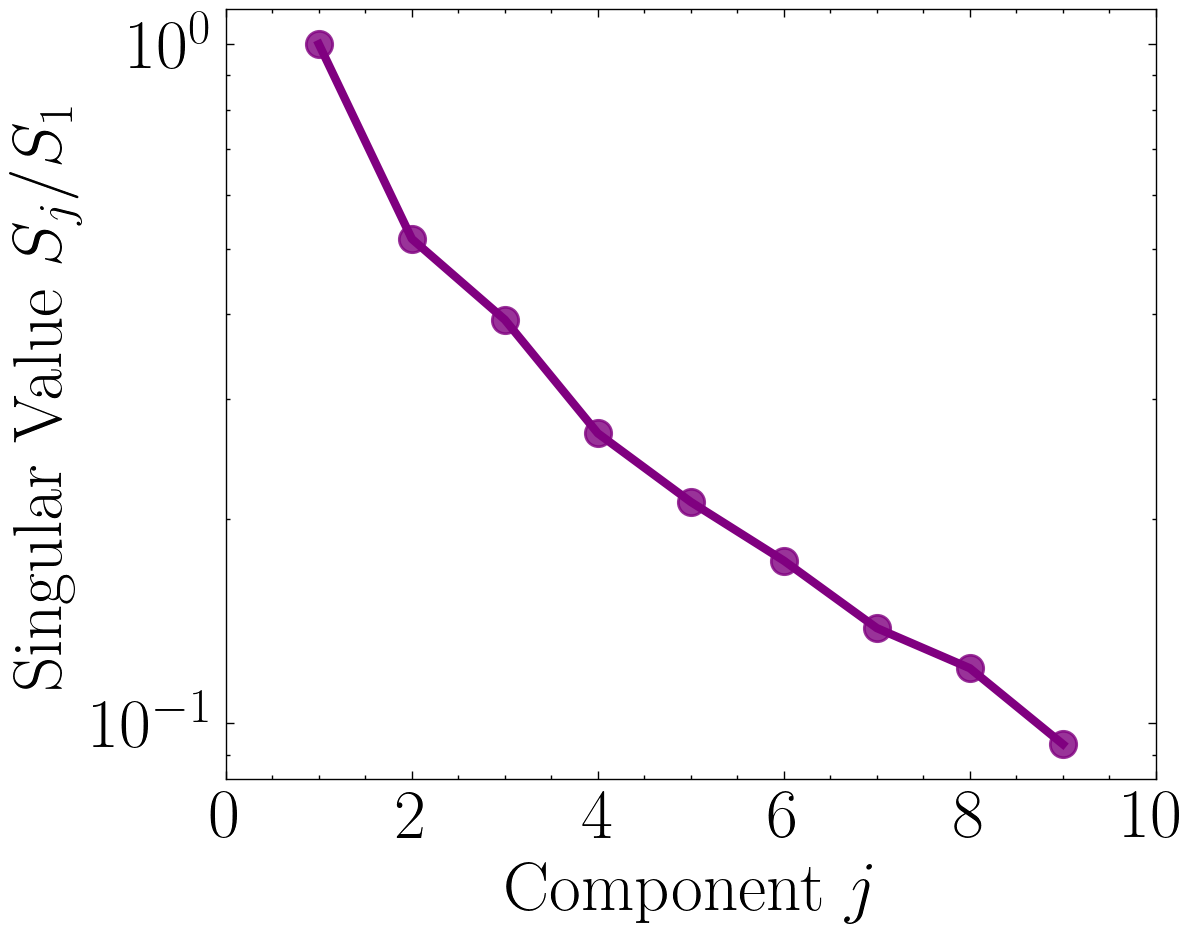

In [24]:
U, S, Vt = np.linalg.svd(model_predictions_radius_train_processed)

print(S)

plt.rc("xtick", labelsize = 25)
plt.rc("ytick", labelsize = 25)
plt.rcParams['text.usetex'] = True
fig, ax = plt.subplots(figsize = (6,5), dpi = 200)

ax.scatter(np.arange(1, S.size ), S[:-1]/S[0], color = "purple", alpha = 0.8, s = 90, marker = 'o')
ax.plot(np.arange(1, S.size ), S[:-1]/S[0], color = "purple", linewidth = 3)

ax.set_xticks([0,2,4,6,8,10])
plt.xlabel("Component $j$", fontsize = 25)
plt.ylabel("Singular Value $S_j/S_1$", fontsize = 25)
plt.yscale("log")
# plt.title('Charge Radii', fontsize = 25)
# plt.savefig('Plots/Radii Data with Bailey/Singular values/Singular Values with FyDr and FyIVP.png')
plt.show()

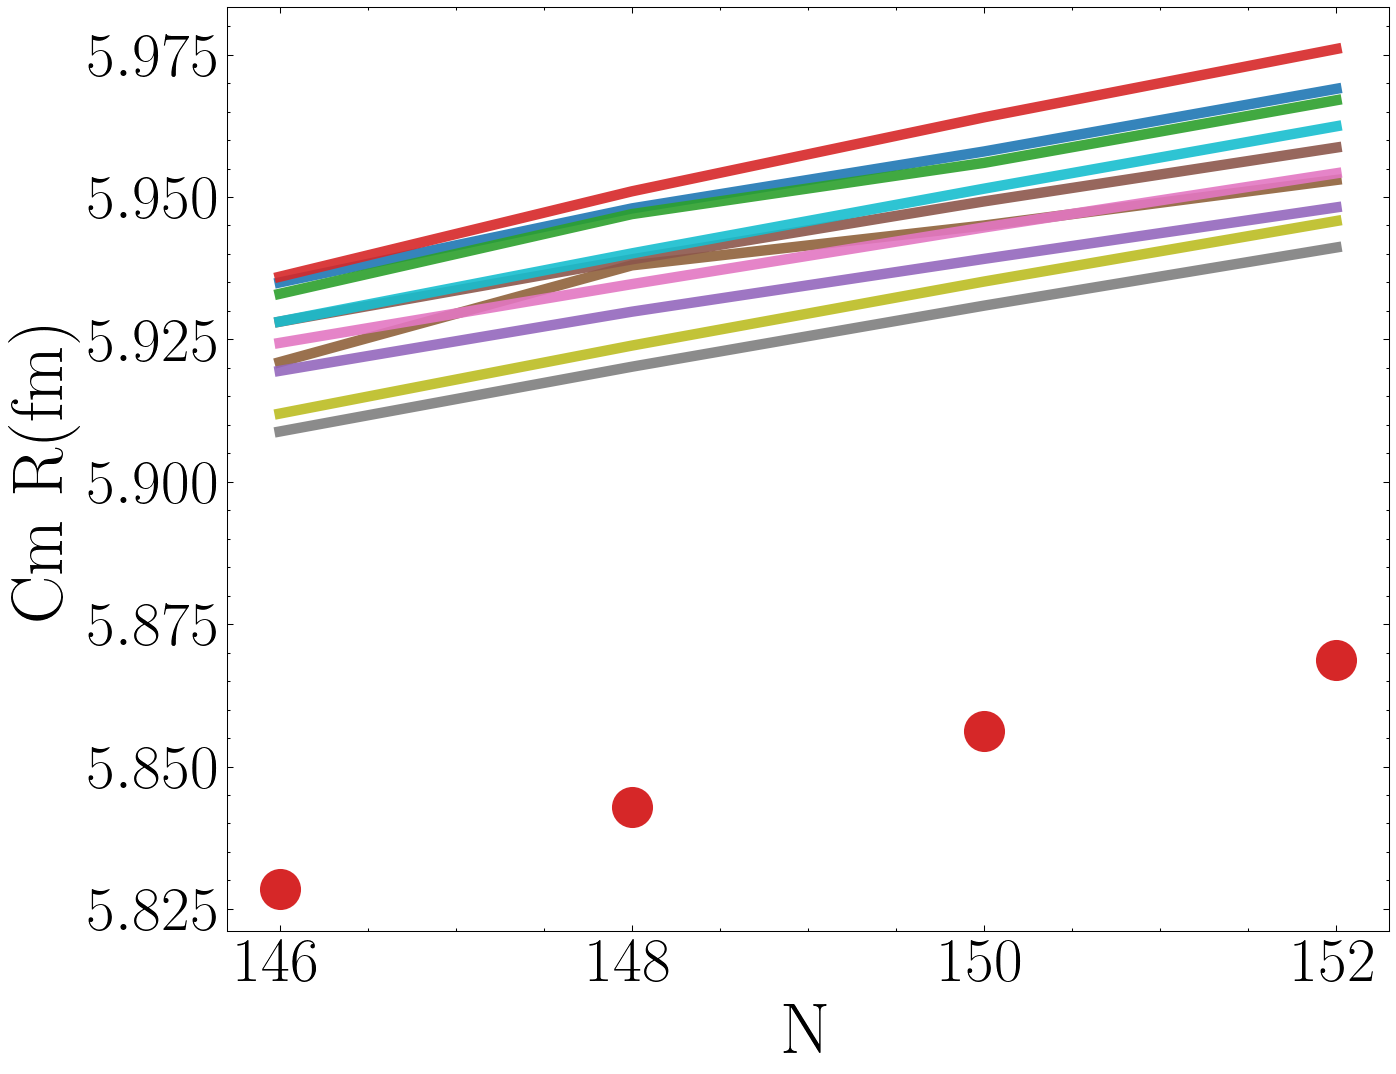

In [36]:
filtered_models_output_radius_list_96 = filtered_models_output_extraction(models_output_radius, \
                                        train_coordinates_radius, val_coordinates_radius, \
                                        test_coordinates_radius, stable_coordinates_radius_df, (96,96))

# I will graph the new models predictions for each isotope with all the models together
plot_model_predictions(filtered_models_output_radius_list_96, models_selected, 'Cm')
plt.savefig('../DNP 2025 Plots/Cm_models.png')
plt.show()

In [37]:
components_kept = 10
U_hat = np.array([U.T[i] for i in range(components_kept)]).T
S_hat = S[:components_kept]
Vt_hat = np.array([Vt[i]/S[i] for i in range(components_kept)])
Vt_hat_normalized=np.array([Vt[i] for i in range(components_kept)])
# Vt_hat = np.array([Vt[i] for i in range(components_kept)])

models_PC_radius = models_PC_output(Vt_hat, model_predictions_radius, predictions_mean_radius, models_output_radius)
models_PC_radius_train = models_PC_output(Vt_hat, model_predictions_radius_train, predictions_mean_radius_train, models_output_radius_train)
models_PC_radius_validation = models_PC_output(Vt_hat, model_predictions_radius_validation, predictions_mean_radius_validation, models_output_radius_validation)
models_PC_radius_test = models_PC_output(Vt_hat, model_predictions_radius_test, predictions_mean_radius_test, models_output_radius_test)

In [39]:
super_params_train = super_params(model_predictions_radius_train, models_output_radius_train['truth'])
supermodel_radius_train = super_params_train.dot(model_predictions_radius_train.T)
supermodel_radius_validation = super_params_train.dot(model_predictions_radius_validation.T)
supermodel_radius_test = super_params_train.dot(model_predictions_radius_test.T)
supermodel_radius_full = super_params_train.dot(model_predictions_radius.T)

supermodel_residuals_radius_train=supermodel_radius_train-models_output_radius_train['truth'].tolist()
supermodel_residuals_radius_validation= supermodel_radius_validation-models_output_radius_validation['truth'].tolist()
supermodel_residuals_radius_test = supermodel_radius_test-models_output_radius_test['truth'].tolist()
supermodel_residuals_radius_full = supermodel_radius_full-models_output_radius['truth'].tolist()

supermodel_sigma_radius_train=np.sqrt(np.sum(supermodel_residuals_radius_train**2) / len(supermodel_residuals_radius_train) )
supermodel_sigma_radius_validation=np.sqrt(np.sum(supermodel_residuals_radius_validation**2) / len(supermodel_residuals_radius_validation) )
supermodel_sigma_radius_test=np.sqrt(np.sum(supermodel_residuals_radius_test**2) / len(supermodel_residuals_radius_test) )
supermodel_sigma_radius_full=np.sqrt(np.sum(supermodel_residuals_radius_full**2) / len(supermodel_residuals_radius_full) )

if centering_data:
    s_radius_validation=[np.linalg.norm(np.array(models_output_radius_validation["truth"].tolist())-predictions_mean_radius_validation)/np.sqrt(len(predictions_mean_radius_validation))]
    s_radius_test=[np.linalg.norm(np.array(models_output_radius_test["truth"].tolist())-predictions_mean_radius_test)/np.sqrt(len(predictions_mean_radius_test))]
    s_radius_train=[np.linalg.norm(np.array(models_output_radius_train["truth"].tolist())-predictions_mean_radius_train)/np.sqrt(len(predictions_mean_radius_train))]
    s_radius_all=[np.linalg.norm(np.array(models_output_radius["truth"].tolist())-predictions_mean_radius)/np.sqrt(len(predictions_mean_radius))]

if centering_data:
    for i in range(1,len(S)):
        res=PC_RMSE_calculator(i, model_predictions_radius_train, predictions_mean_radius_train, models_output_radius_train, models_output_radius_list, model_predictions_radius_list, U, S, Vt)
        s_radius_all.append(res[0])
        s_radius_train.append(res[1])
        s_radius_validation.append(res[2])
        
        s_radius_test.append(res[3])

[0.09972383 0.09928466 0.09977751 0.09940401 0.10037757 0.10084178
 0.10057134 0.10009592 0.09995123 0.09997216]
0.01759013241764552
[0.09922513 0.09916378 0.09928532 0.0993389  0.10053951 0.10056909
 0.1001777  0.10077343 0.1007278  0.10019933]
0.01759010920802031
[ 0.21684977 -0.12510071  0.04661433  0.2698414   0.29970075 -0.0157777
  0.08305238  0.03655685  0.0868801   0.10138282]
0.01645523906964307
[ 0.16670444  0.11628023 -0.05303643  0.17832507  0.59783333 -0.05632227
  0.10026527 -0.07257553  0.10180322 -0.07927732]
0.015678273504520637
[ 0.40057192  0.09700712 -0.24414538  0.31817222  0.4195124   0.20055079
  0.00923564 -0.10546951  0.35938136 -0.45481654]
0.014653344407717045
[ 0.60652589 -0.00434052  0.0161904   0.08105176  0.45066402 -0.04263367
  0.08390777  0.30320189  0.31383967 -0.80840722]
0.01372601617045754
[ 5.34102913e-01  2.87619574e-04  3.06545873e-02  1.63205472e-01
  4.67979794e-01 -6.19867126e-04  5.49682900e-02  3.59976316e-01
  2.44773021e-01 -8.55328145e-0

<>:15: SyntaxWarning: invalid escape sequence '\d'
<>:18: SyntaxWarning: invalid escape sequence '\d'
<>:22: SyntaxWarning: invalid escape sequence '\d'
<>:15: SyntaxWarning: invalid escape sequence '\d'
<>:18: SyntaxWarning: invalid escape sequence '\d'
<>:22: SyntaxWarning: invalid escape sequence '\d'
C:\Users\leduc\AppData\Local\Temp\ipykernel_27740\4099733621.py:15: SyntaxWarning: invalid escape sequence '\d'
  ax.plot(np.arange(0,len(s_radius_train[:-1])), s_radius_train[:-1],color=color_train,linewidth=3,label='$f^\dagger(\mathcal{X}_0^{tr})$')
C:\Users\leduc\AppData\Local\Temp\ipykernel_27740\4099733621.py:18: SyntaxWarning: invalid escape sequence '\d'
  ax.plot(np.arange(0,len(s_radius_validation[:-1])), s_radius_validation[:-1],color=color_validation,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{va})$")
C:\Users\leduc\AppData\Local\Temp\ipykernel_27740\4099733621.py:22: SyntaxWarning: invalid escape sequence '\d'
  ax.plot(np.arange(0,len(s_radius_test[:-1])), s_radius_test[:

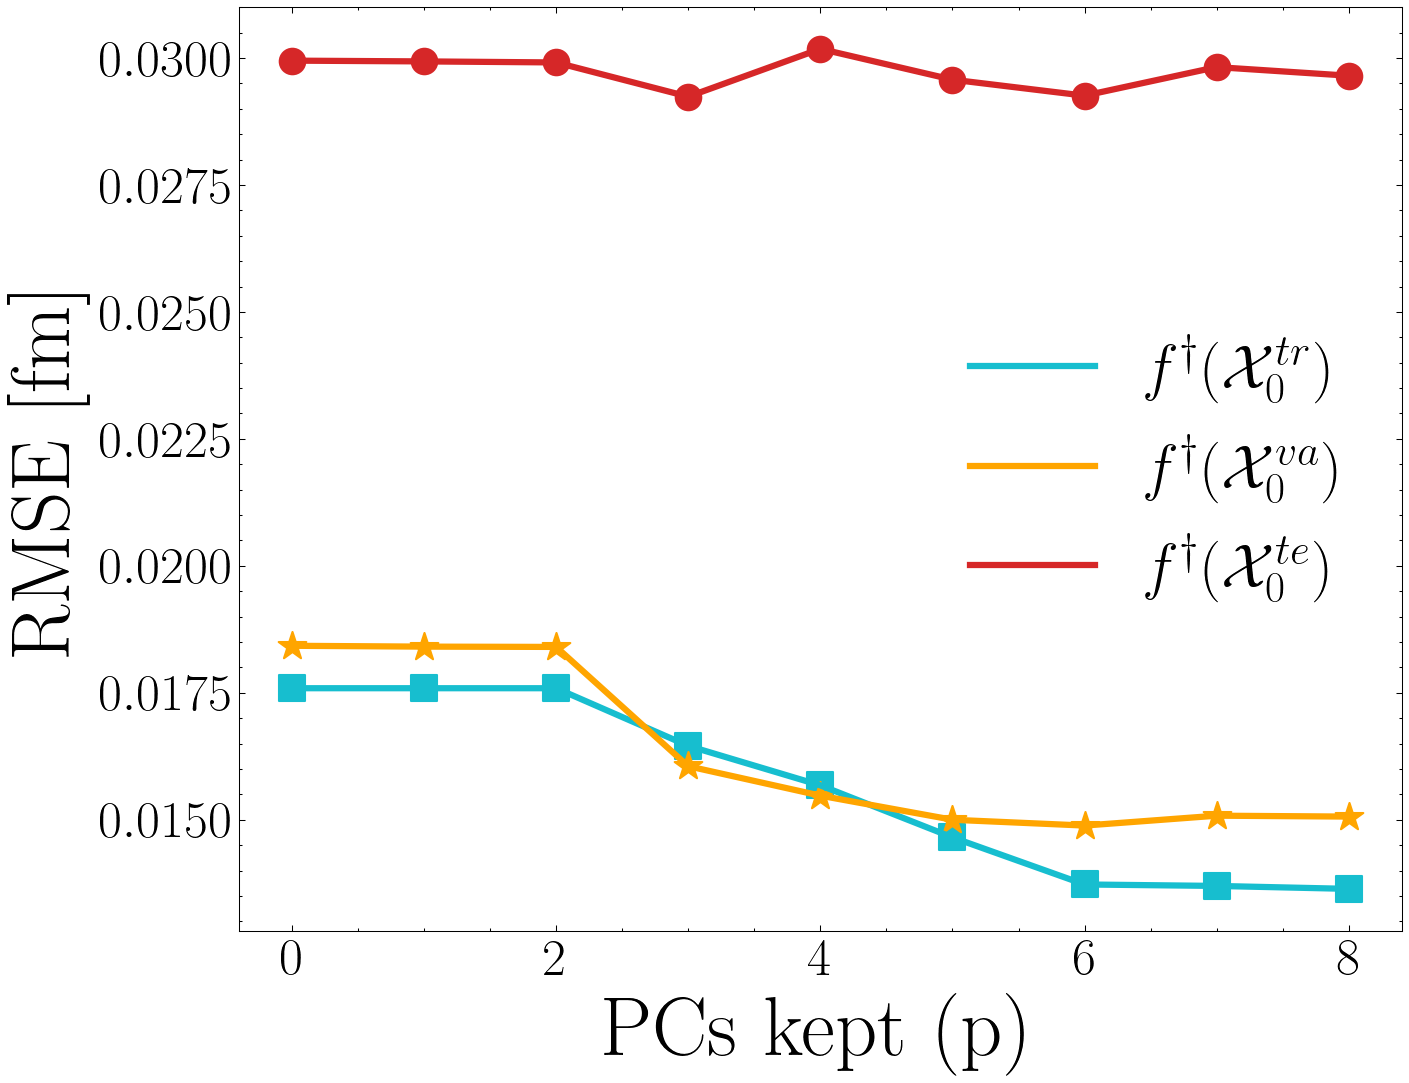

In [114]:
plt.rc("xtick", labelsize=25)
plt.rc("ytick", labelsize=25)

plt.rcParams['text.usetex'] = True

fig, ax = plt.subplots(figsize=(10,8),dpi=150)
fig.patch.set_facecolor('white')



size_points=150


ax.scatter(np.arange(0,len(s_radius_train[:-1])), s_radius_train[:-1],color=color_train,s=size_points,marker=marker_train)
ax.plot(np.arange(0,len(s_radius_train[:-1])), s_radius_train[:-1],color=color_train,linewidth=3,label='$f^\dagger(\mathcal{X}_0^{tr})$')

ax.scatter(np.arange(0,len(s_radius_validation[:-1])), s_radius_validation[:-1],color=color_validation,s=size_points*1.3,marker=marker_validation)
ax.plot(np.arange(0,len(s_radius_validation[:-1])), s_radius_validation[:-1],color=color_validation,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{va})$")


ax.scatter(np.arange(0,len(s_radius_test[:-1])), s_radius_test[:-1],color=color_test,s=size_points,marker=marker_test)
ax.plot(np.arange(0,len(s_radius_test[:-1])), s_radius_test[:-1],color=color_test,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{te})$")

# ax.axhline(y=supermodel_sigma_radius_train,color=color_train,label="BMC$(\mathcal{X}_0^{tr})$",linestyle='dashed',linewidth=3)
# ax.axhline(y=supermodel_sigma_radius_validation,color=color_validation,label="BMC$(\mathcal{X}_0^{va})$",linestyle='dashed',linewidth=3)
# ax.axhline(y=supermodel_sigma_radius_test,color=color_test,label="BMC$(\mathcal{X}_0^{te})$",linestyle='dashed',linewidth=3)








# ax.set_yticks([0.2,0.5,1,2])


# ax.set_yscale('log')
ax.set_xlabel(r'PCs kept (p)',fontsize=40)
ax.set_ylabel(r' RMSE [fm]',fontsize=40);
ax.set_xticks([0,2,4,6,8])

# plt.ylim(2.5*10**(-1),2.3)

plt.legend(fontsize=30, loc = 'right')
# plt.savefig('Plots/Heterogenous RMSE change as number of PCs')
# plt.title('Radius Calibration for Ca, Ni, Sn, Pb ', fontsize = 25)
plt.savefig('../DNP 2025 Plots/RMSE_original.png')
# plt.legend(fontsize=30)
plt.show()

In [47]:
components_kept = 2
U_hat = np.array([U.T[i] for i in range(components_kept)]).T
S_hat = S[:components_kept]
Vt_hat = np.array([Vt[i]/S[i] for i in range(components_kept)])
Vt_hat_normalized=np.array([Vt[i] for i in range(components_kept)])

y_radius = models_output_radius_train['truth'] - predictions_mean_radius_train

models_PC_radius = models_PC_output(Vt_hat, model_predictions_radius, predictions_mean_radius, models_output_radius)
models_PC_radius_train = models_PC_output(Vt_hat, model_predictions_radius_train, predictions_mean_radius_train, models_output_radius_train)
models_PC_radius_validation = models_PC_output(Vt_hat, model_predictions_radius_validation, predictions_mean_radius_validation, models_output_radius_validation)
models_PC_radius_test = models_PC_output(Vt_hat, model_predictions_radius_test, predictions_mean_radius_test, models_output_radius_test)

In [ ]:
def gibbs_sampler(y, X, iterations,prior_info):
    #Make sure that "y" has the correct structure. If data is being centered, it should have the mean already substracted
    b_mean_prior, b_mean_cov, nu0, sigma20  =  prior_info
    #From A_First_Course_in_Bayesian_Statistical_Methods (page ~ 159), 
    #nu0 represent the effective prior samples and sigma2_0 represents the expected prior variance
    
    b_mean_cov_inv=np.linalg.inv(b_mean_cov)
    n = len(y) # We are still taking mass and radius to be the same size
    
    X_T_X=X.T.dot(X)
    X_T_X_inv = np.linalg.inv(X_T_X)

    b_data = X_T_X_inv.dot(X.T).dot(y)

    
    
    supermodel=X.dot(b_data)
    

    residuals = y - supermodel 

    
    
    sigma2 = np.sum(residuals**2) / len(residuals) 
    cov_matrix = sigma2 * X_T_X_inv
    
    samples = []
    
    for i in range(iterations):
        # Sample from the conditional posterior of bs given sigma2 and data

        
        cov_matrix = np.linalg.inv(X_T_X/sigma2
                                   + b_mean_cov_inv)
        
        mean_vector = cov_matrix.dot(        b_mean_cov_inv.dot(b_mean_prior)+ X.T.dot(y)/sigma2  )
        
        
        b_current = np.random.multivariate_normal(mean_vector, cov_matrix)

        
        
        
        # Sample from the conditional posterior of sigma2 given bs and data
        supermodel=X.dot(b_current)
        
        residuals = y - supermodel 
        
        
        shape_post = (nu0 + n)/2.
        scale_post = (nu0*sigma20 + np.sum(residuals**2))/2.0
        # sigma2 = 1 / np.random.gamma(shape_post, 1/scale_post)
        sigma2 = 1 / np.random.default_rng().gamma(shape_post, 1/scale_post)
        
        
        samples.append(np.append(b_current,np.sqrt(sigma2)))
    


    return np.array(samples)

In [49]:
X_train = U_hat.copy()

nu0_chosen, sigma20_chosen = 1, 0.01
samples = gibbs_sampler(y_radius,X_train, 100000,[np.full(components_kept,0),\
                                                  np.abs(np.diag(S[:components_kept]**2)), nu0_chosen, sigma20_chosen])

In [50]:
# This code will help us to calculate the weight of the individual models from the weight of the principal components
model_weights = []
for beta in samples:
    model_weights.append(np.dot(beta[:-1], Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0])))
model_weights= np.array(model_weights)

In [55]:
filtered_models_output_radius_20 = filtered_models_output_radius_list_20[0]
filtered_model_predictions_radius_20 = filtered_models_output_radius_20.iloc[:,3:-1].values

filtered_models_output_radius_28 = filtered_models_output_radius_list_28[0]
filtered_model_predictions_radius_28 = filtered_models_output_radius_28.iloc[:,3:-1].values

filtered_models_output_radius_50 = filtered_models_output_radius_list_50[0]
filtered_model_predictions_radius_50 = filtered_models_output_radius_50.iloc[:,3:-1].values

filtered_models_output_radius_82 = filtered_models_output_radius_list_82[0]
filtered_model_predictions_radius_82 = filtered_models_output_radius_82.iloc[:,3:-1].values

rndm_20, [lower_radius_20, median_radius_20, upper_radius_20] = rndm_m_random_calculator(filtered_model_predictions_radius_20, samples, Vt_hat)
rndm_82, [lower_radius_82, median_radius_82, upper_radius_82] = rndm_m_random_calculator(filtered_model_predictions_radius_82, samples, Vt_hat)
rndm_28, [lower_radius_28, median_radius_28, upper_radius_28] = rndm_m_random_calculator(filtered_model_predictions_radius_28, samples, Vt_hat)
rndm_50, [lower_radius_50, median_radius_50, upper_radius_50] = rndm_m_random_calculator(filtered_model_predictions_radius_50, samples, Vt_hat)

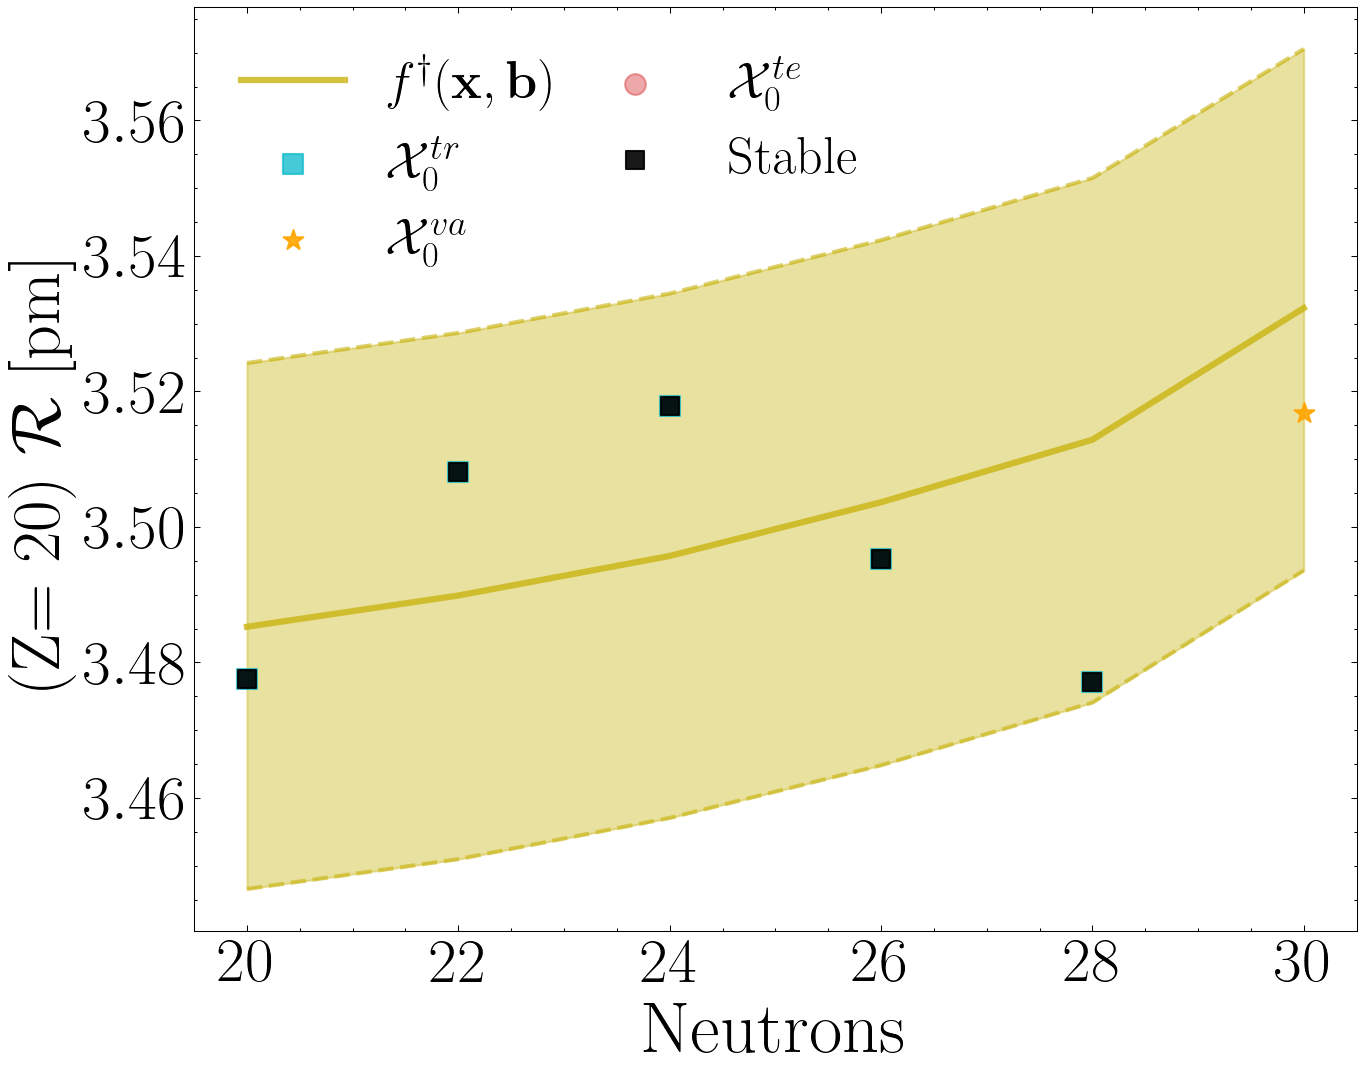

In [115]:
supermodel_predictions_radius_range_20 = [lower_radius_20, median_radius_20, upper_radius_20]
# title = 'Radius Calibration'
color_now = "#C9B411D2"
# savefig_20_radius = 'Plots/Heterogeneous Real Scaled Analysis/Radius predictions/Unconstrained CR forecasts for Z = 20 - Radius Analysis - 2PCs.png'
plot_filtered_supermodel(supermodel_predictions_radius_range_20, filtered_models_output_radius_list_20, color_now, 20, 'pm', 'R', 'Unconstrained', components_kept )
plt.savefig('../DNP 2025 Plots/Calcium_BMM_original.png')
plt.show()

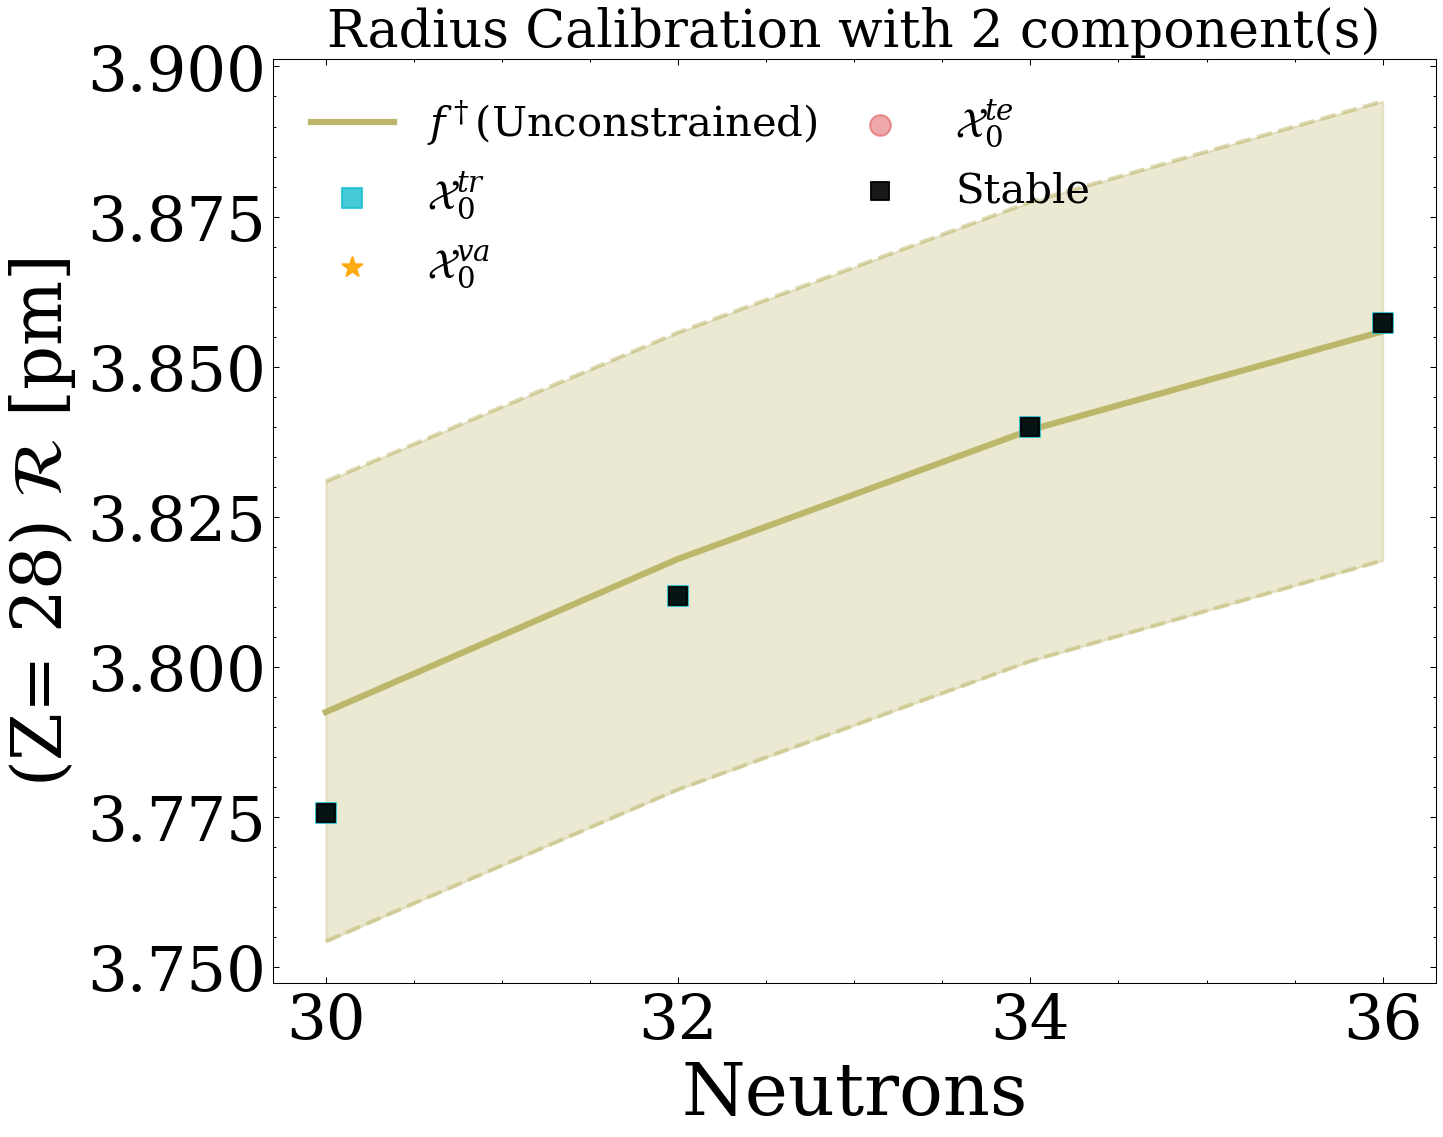

In [57]:
supermodel_predictions_radius_range_28 = [lower_radius_28, median_radius_28, upper_radius_28]
# title = 'Radius Calibration'
# savefig_20_radius = 'Plots/Heterogeneous Real Scaled Analysis/Radius predictions/Unconstrained CR forecasts for Z = 20 - Radius Analysis - 2PCs.png'
plot_filtered_supermodel(supermodel_predictions_radius_range_28, filtered_models_output_radius_list_28, 28, 'pm', 'R', 'Unconstrained', components_kept )
# plt.savefig(f'Plots/Radii Data with Bailey/BMC Radii/Ni 28 - Unconstrained BMM with {components_kept} components - Fy_Dr and Fy_IVP')
plt.show()

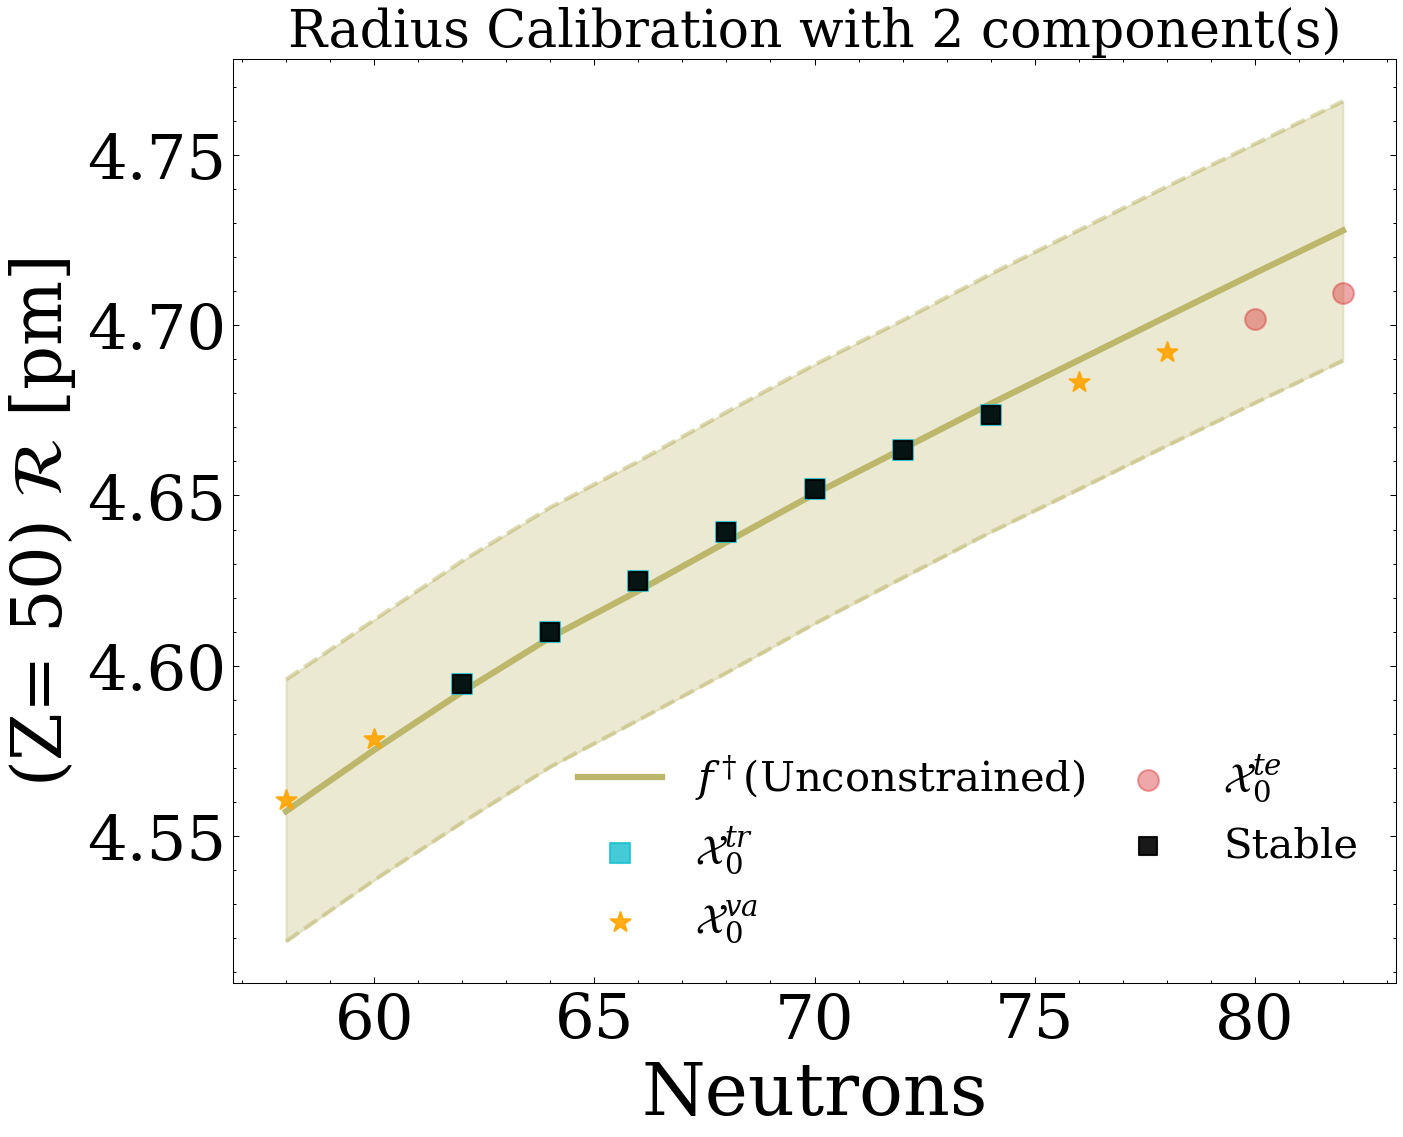

In [58]:
supermodel_predictions_radius_range_50 = [lower_radius_50, median_radius_50, upper_radius_50]
# title = 'Radius Calibration'
# savefig_20_radius = 'Plots/Heterogeneous Real Scaled Analysis/Radius predictions/Unconstrained CR forecasts for Z = 20 - Radius Analysis - 2PCs.png'
plot_filtered_supermodel(supermodel_predictions_radius_range_50, filtered_models_output_radius_list_50, 50, 'pm', 'R', 'Unconstrained', components_kept )
# plt.savefig(f'Plots/Radii Data with Bailey/BMC Radii/Zn 50 - Unconstrained BMM with {components_kept} components - - Fy_Dr and Fy_IVP')
plt.show()

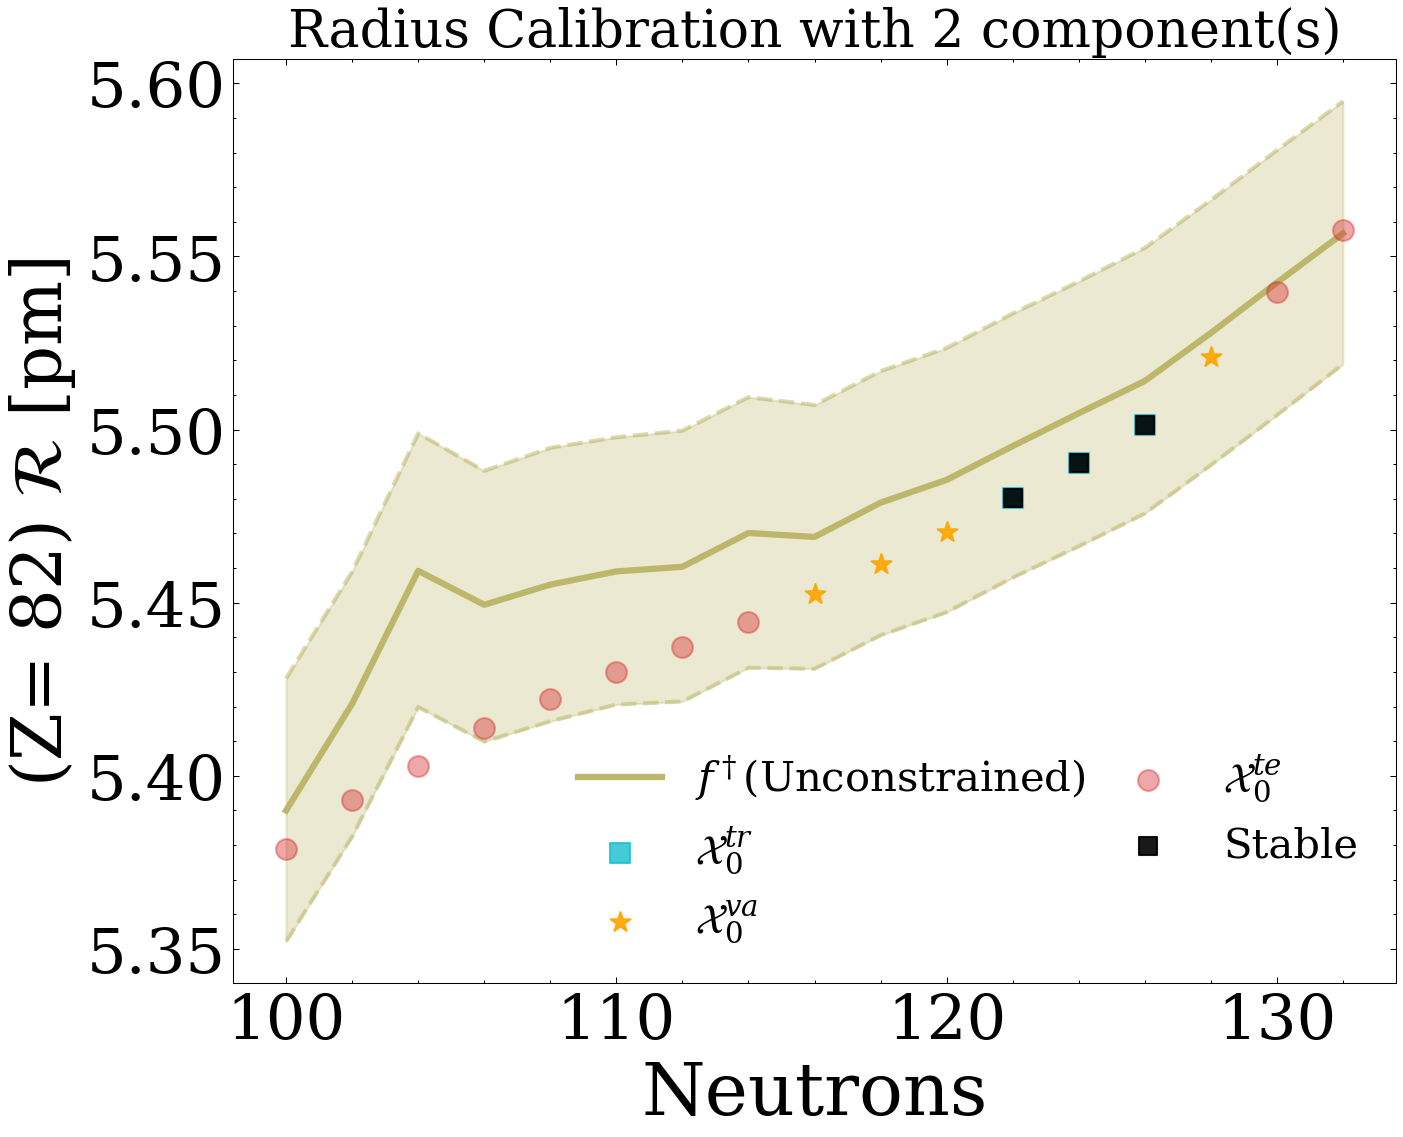

In [59]:
supermodel_predictions_radius_range_82 = [lower_radius_82, median_radius_82, upper_radius_82]
# title = 'Radius Calibration'
# savefig_20_radius = 'Plots/Heterogeneous Real Scaled Analysis/Radius predictions/Unconstrained CR forecasts for Z = 20 - Radius Analysis - 2PCs.png'
plot_filtered_supermodel(supermodel_predictions_radius_range_82, filtered_models_output_radius_list_82, 82, 'pm', 'R', 'Unconstrained', components_kept )
# plt.savefig(f'Plots/Radii Data with Bailey/BMC Radii/Pb 82 - Unconstrained BMM with {components_kept} components - Fy_Dr and Fy_IVP.png')
plt.show()

In [60]:
def gibbs_sampler_simplex(y, X, iterations,prior_info,burn=10000,stepsize=0.001):
    if centering_data == False:
        print("Only available for centering data")
        return 
    #Make sure that "y" has the correct structure. If data is being centered, it should have the mean already substracted
#     b_mean_prior, b_mean_cov, nu0, sigma20  =  prior_info
    
    nu0, sigma20  =  prior_info   #Since our prior is only in \sigma, we are letting the \betas be free beyond the simplex
    
    #From A_First_Course_in_Bayesian_Statistical_Methods (page ~ 159), nu0 represent the effective prior samples and sigma2_0 represents the expected prior variance
    
    cov_matrix_step=np.diag(S_hat**2*stepsize**2)
    
    n = len(y)
    
    #Initializing the starting point at the average of all the models
    b_current = np.full(len(X),0)

    
    
    supermodel_current=X.T.dot(b_current)
    

    residuals_current = y - supermodel_current 

    
  
    log_likelihood_current= -np.sum(residuals_current**2)
    
    
    sigma2 = -log_likelihood_current/ len(residuals_current) 

    
    
    samples = []
    acceptance=0
    
    for i in range(burn):
        # Sample from the conditional posterior of bs given sigma2 and data       
        b_proposed =  np.random.multivariate_normal(b_current, cov_matrix_step)
        
        omegas_proposed=np.dot(b_proposed,Vt_hat) + bias0

        
            #Comment this line and uncomment the next if you want to check MCMC without the simplex  
        if  np.any(omegas_proposed < 0):
            pass
        
#         if 1>2:
#             pass
        
        else:
            
            supermodel_proposed=X.T.dot(b_proposed)
    
            residuals_proposed = y - supermodel_proposed 

            log_likelihood_proposed= -np.sum(residuals_proposed**2)
            
#           Calculate the acceptance probability
            acceptance_prob = min(1, np.exp(   (+log_likelihood_proposed - log_likelihood_current)/sigma2   ))

            # Accept or reject the proposal
            if np.random.uniform() < acceptance_prob:
                b_current = np.copy(b_proposed)
                log_likelihood_current=log_likelihood_proposed

        shape_post = (nu0 + n)/2.
        
        
#         scale_post = (nu0*sigma20 - log_likelihood_current/len(residuals_current))/2.0
        
        scale_post = (nu0*sigma20 - log_likelihood_current)/2.0

        sigma2 = 1 / np.random.default_rng().gamma(shape_post, 1/scale_post)
        
        
#         samples.append(np.append(b_current,np.sqrt(sigma2)))
        
        
  

    for i in range(iterations):
        # Sample from the conditional posterior of bs given sigma2 and data       
        b_proposed =  np.random.multivariate_normal(b_current, cov_matrix_step)
        
        omegas_proposed=np.dot(b_proposed,Vt_hat) + bias0

    #Comment this line and uncomment the next if you want to check MCMC without the simplex    
        if  np.any(omegas_proposed < 0):
            pass
        
#         if 1>2:
#             pass
        else:
            supermodel_proposed=X.T.dot(b_proposed)
    
            residuals_proposed = y - supermodel_proposed 

            log_likelihood_proposed= -np.sum(residuals_proposed**2)
            
#           Calculate the acceptance probability
            acceptance_prob = min(1, np.exp(   (+log_likelihood_proposed - log_likelihood_current)/sigma2   ))

            # Accept or reject the proposal
            if np.random.uniform() < acceptance_prob:
                b_current = np.copy(b_proposed)
                log_likelihood_current=log_likelihood_proposed
                acceptance=acceptance+1

        shape_post = (nu0 + n)/2.
        
        scale_post = (nu0*sigma20 - log_likelihood_current)/2.0

        sigma2 = 1 / np.random.default_rng().gamma(shape_post, 1/scale_post)
        
        
        samples.append(np.append(b_current,np.sqrt(sigma2)))        
        
        
        
        
        
        
    

    print("percentage accepted:", round(acceptance/iterations*100))
    return np.array(samples)

In [64]:
bias0=np.full(len(model_predictions_radius_train.T),1/len(model_predictions_radius_train.T))
#This term will be added to the \omegas when obtaining them from the \betas to account for centering the data

In [65]:
%%time
samples_simplex=gibbs_sampler_simplex(y_radius, X_train.T, 500000,[nu0_chosen, sigma20_chosen],burn=100000,stepsize=0.06)

percentage accepted: 35
CPU times: total: 1min 15s
Wall time: 1min 16s


In [66]:
# This code will help us to calculate the weight of the individual models from the weight of the principal components
model_weights_simplex = []
for beta_simplex in samples_simplex:
    model_weights_simplex.append(np.dot(beta_simplex[:-1], Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0])))
model_weights_simplex= np.array(model_weights_simplex)

In [67]:
rndm_simplex_20, [lower_radius_simplex_20, median_radius_simplex_20, upper_radius_simplex_20] = rndm_m_random_calculator(filtered_model_predictions_radius_20, samples_simplex, Vt_hat)
rndm_simplex_28, [lower_radius_simplex_28, median_radius_simplex_28, upper_radius_simplex_28] = rndm_m_random_calculator(filtered_model_predictions_radius_28, samples_simplex, Vt_hat)
rndm_simplex_50, [lower_radius_simplex_50, median_radius_simplex_50, upper_radius_simplex_50] = rndm_m_random_calculator(filtered_model_predictions_radius_50, samples_simplex, Vt_hat)
rndm_simplex_82, [lower_radius_simplex_82, median_radius_simplex_82, upper_radius_simplex_82] = rndm_m_random_calculator(filtered_model_predictions_radius_82, samples_simplex, Vt_hat)


In [68]:
# To create the empirical coverage graph, we need to sample bmm predictions from the parameters generated
# from both unconstrained and simplex sampling strategies
rndm_simplex_total, [lower_radius_simplex_total, median_radius_simplex_total, upper_radius_simplex_total] = rndm_m_random_calculator(model_predictions_radius, samples_simplex, Vt_hat)
rndm_simplex_train, [lower_radius_simplex_train, median_radius_simplex_train, upper_radius_simplex_train] = rndm_m_random_calculator(model_predictions_radius_train, samples_simplex, Vt_hat)
rndm_simplex_val, [lower_radius_simplex_val, median_radius_simplex_val, upper_radius_simplex_val] = rndm_m_random_calculator(model_predictions_radius_validation, samples_simplex, Vt_hat)
rndm_simplex_test, [lower_radius_simplex_test, median_radius_simplex_test, upper_radius_simplex_test] = rndm_m_random_calculator(model_predictions_radius_test, samples_simplex, Vt_hat)

rndm_total, [lower_radius_total, median_radius_total, upper_radius_total] = rndm_m_random_calculator(model_predictions_radius, samples, Vt_hat)
rndm_train, [lower_radius_train, median_radius_train, upper_radius_train] = rndm_m_random_calculator(model_predictions_radius_train, samples, Vt_hat)
rndm_val, [lower_radius_val, median_radius_val, upper_radius_val] = rndm_m_random_calculator(model_predictions_radius_validation, samples, Vt_hat)
rndm_test, [lower_radius_test, median_radius_test, upper_radius_test] = rndm_m_random_calculator(model_predictions_radius_test, samples, Vt_hat)

In [69]:
percentiles = np.arange(0,101,5)

coverage_unconstrained_train = coverage(percentiles, rndm_train, models_output_radius_train, 'truth' )
coverage_unconstrained_validation = coverage(percentiles, rndm_val, models_output_radius_validation, 'truth' )
coverage_unconstrained_test = coverage(percentiles, rndm_test, models_output_radius_test, 'truth' )

coverage_simplex_train = coverage(percentiles, rndm_simplex_train, models_output_radius_train, 'truth' )
coverage_simplex_validation = coverage(percentiles, rndm_simplex_val, models_output_radius_validation, 'truth' )
coverage_simplex_test = coverage(percentiles, rndm_simplex_test, models_output_radius_test, 'truth' )


<>:22: SyntaxWarning: invalid escape sequence '\%'
<>:23: SyntaxWarning: invalid escape sequence '\%'
<>:22: SyntaxWarning: invalid escape sequence '\%'
<>:23: SyntaxWarning: invalid escape sequence '\%'
C:\Users\leduc\AppData\Local\Temp\ipykernel_27740\1167468297.py:22: SyntaxWarning: invalid escape sequence '\%'
  plt.xlabel('Credible Interval (\%)',fontsize=22)
C:\Users\leduc\AppData\Local\Temp\ipykernel_27740\1167468297.py:23: SyntaxWarning: invalid escape sequence '\%'
  plt.ylabel('Coverage (\%)',fontsize=22)


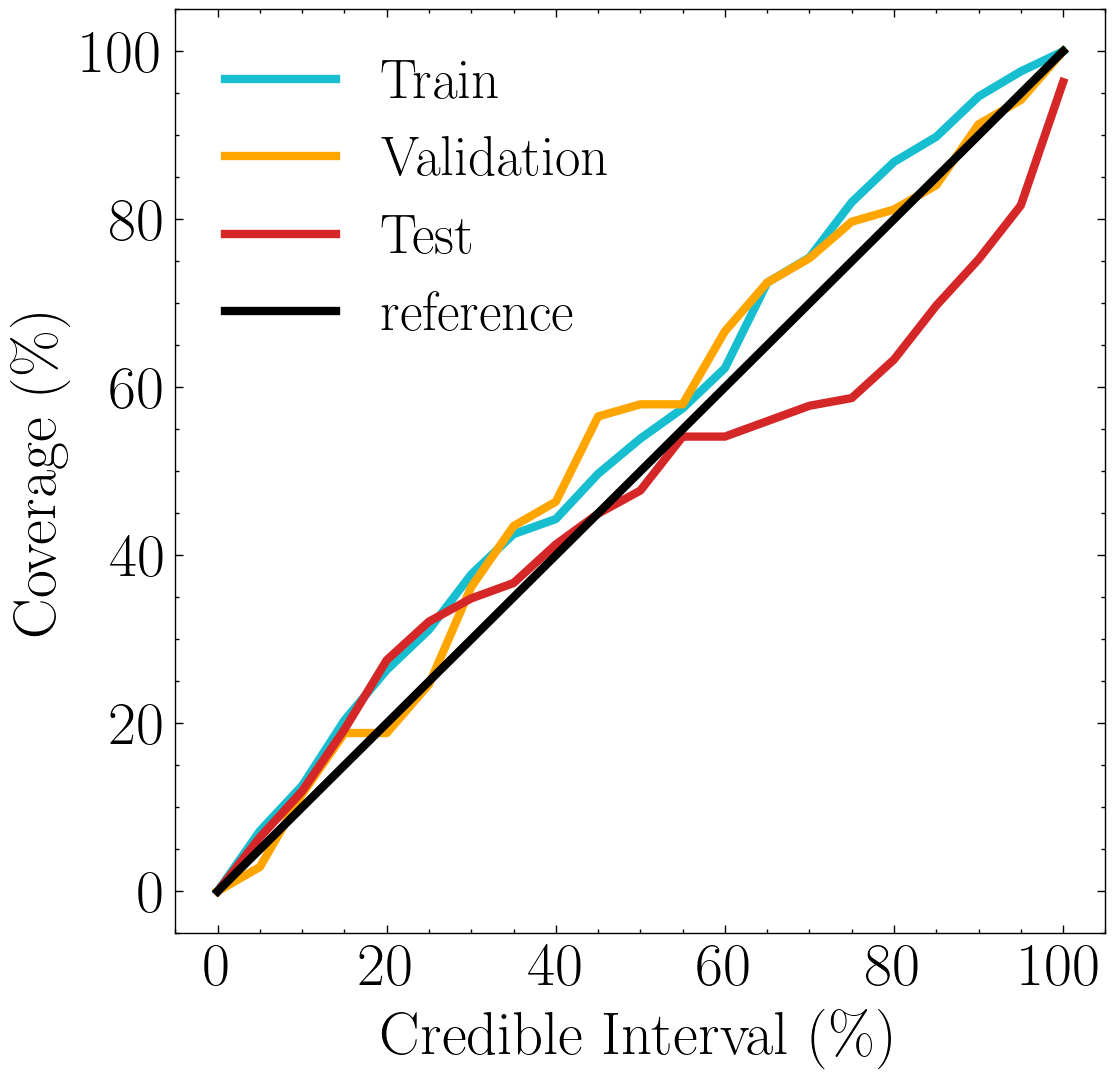

In [74]:
plt.rc("xtick", labelsize=22)
plt.rc("ytick", labelsize=22)

plt.rcParams['text.usetex'] = True
# Plotting the results
plt.figure(figsize=(6, 6),dpi=200)

width_line=2

plt.plot(percentiles, coverage_unconstrained_train, label='Train',color=color_train,linewidth= 3)
plt.plot(percentiles, coverage_unconstrained_validation, label='Validation',color=color_validation,linewidth=3)
plt.plot(percentiles, coverage_unconstrained_test, label='Test',color=color_test,linewidth=3)


# plt.plot(percentiles, coverage_simplex_train,linestyle='dashed', label='Training Simplex',color=color_train,linewidth=width_line)
# plt.plot(percentiles, coverage_simplex_validation, linestyle='dashed',label='Validation Simplex',color=color_validation,linewidth=width_line)
# plt.plot(percentiles, coverage_simplex_test,linestyle='dashed', label='Test Simplex',color=color_test,linewidth=width_line)



plt.plot(percentiles, percentiles,label='reference',color='k',linewidth=3)
plt.xlabel('Credible Interval (\%)',fontsize=22)
plt.ylabel('Coverage (\%)',fontsize=22)

plt.xticks(ticks=[0, 20,40,60,80,100])

# plt.title('Coverage of Observed Data Points by Credible Intervals')
# plt.grid(True)
plt.legend(fontsize=20)

plt.savefig('../DNP 2025 Plots/EC_original.png')
plt.show()